# Demo 4: Reducing data to a single dimension based on distance to a control behavior distribution

Sedona Ewbank (snewbank@stanford.edu), 25-02-06

## Import dependencies

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy
from scipy import optimize, stats, special
import numpy as np
import importlib
import os
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

#import utils
from utils import analysis, plot, metadata

importlib.reload(analysis)
importlib.reload(plot)
importlib.reload(metadata)

<module 'utils.metadata' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/metadata.py'>

In [3]:
config_path="/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/config_PS.yaml"
save_path="/Users/snewbank/Desktop/grpmtg/"
save=True

#Load config
config = metadata.load_project(config_path)

## Exercise 1: Collapsing categorical, time-series data into 1D time series difference from control group (dose-response)


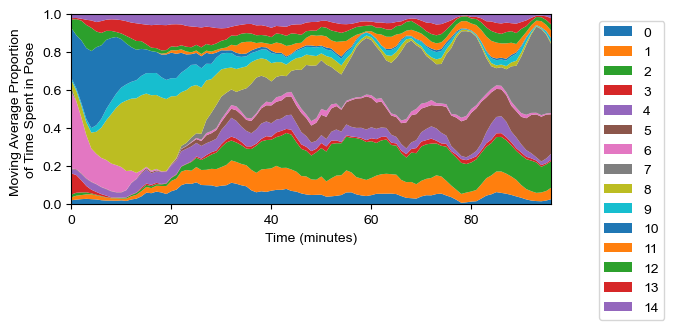

In [4]:
group="k10iv"
labels_df = analysis.get_module_labels(config,0,60*50,subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 30, 100)

In [5]:
selected_subgroups=["saliv"]
binsize=1200
labels_df = analysis.get_module_labels(config,0,60*20,subgroups=["saliv"])
control_usage_feats = analysis.get_module_usage(config,labels_df,binsize)
control_usage_feats.to_df()



binsize=60
selected_subgroups=["saliv","k1iv","k5iv","k10iv"]
labels_df = analysis.get_module_labels(config,0,60*20,subgroups=selected_subgroups)
exp_usage_feats = analysis.get_module_usage(config,labels_df,binsize)

exp_usage_feats_nobins = exp_usage_feats.collapse_timebins()
#picks, pick_names = analysis.feat_select(exp_usage_feats_nobins, method="f", n_feats=5, verbose=True)

In [107]:
exp_usage_ssd.loc[config["subgroups"][group]]

,0,60,120,180,240,300,360,420,480,540,...,2400,2460,2520,2580,2640,2700,2760,2820,2880,2940
2023-05-15_16-47-52_bf03_k10iv,0.539348,0.719836,0.399958,0.761849,0.49024,0.435223,0.30088,0.243997,0.228985,0.313094,...,0.021127,0.054702,0.132622,0.226234,0.153947,0.024022,0.112903,0.186086,0.072773,0.050833
2023-05-15_18-18-22_bf04_k10iv,0.531993,0.498094,0.439409,0.235163,0.229118,0.348348,0.407302,0.355607,0.418724,0.421841,...,0.374104,0.278606,0.077295,0.086237,0.010058,0.26692,0.612197,0.662461,0.728689,0.632484
2023-05-25_14-30-54_bm02_k10iv,0.260495,0.186667,0.292622,0.308747,0.330779,0.614387,0.40984,0.331487,0.259508,0.182101,...,0.650186,0.349839,0.045495,0.053129,0.040885,0.045821,0.132575,0.294808,0.419332,0.405594
2023-05-31_17-08-06_bf01_k10iv,0.626452,0.485546,0.513607,0.340881,0.688393,0.602939,0.464479,0.381189,0.323731,0.366824,...,0.167425,0.087501,0.055199,0.056946,0.059589,0.137366,0.039169,0.029067,0.217295,0.083473
2023-07-13_15-45-26_bm03_k10iv,0.188769,0.2456,0.551808,0.312874,0.259775,0.316017,0.507331,0.510617,0.452105,0.164535,...,0.110879,0.211387,0.192252,0.175789,0.083014,0.140307,0.166126,0.201014,0.149383,0.25065
2023-07-14_13-56-09_bm01_k10iv,1.030693,1.030693,1.030693,1.030693,1.030693,1.030693,0.756801,0.277425,0.079854,0.176743,...,0.401784,0.082578,0.038654,0.065927,0.052555,0.018355,0.232178,0.371857,0.462967,0.054806
2023-07-18_18-19-50_bm04_k10iv,1.029556,1.003761,0.210394,0.17049,0.34886,0.253539,0.213299,0.17018,0.199104,0.219843,...,0.038049,0.09099,0.027154,0.054376,0.015177,0.03022,0.019407,0.045372,0.078164,0.044904


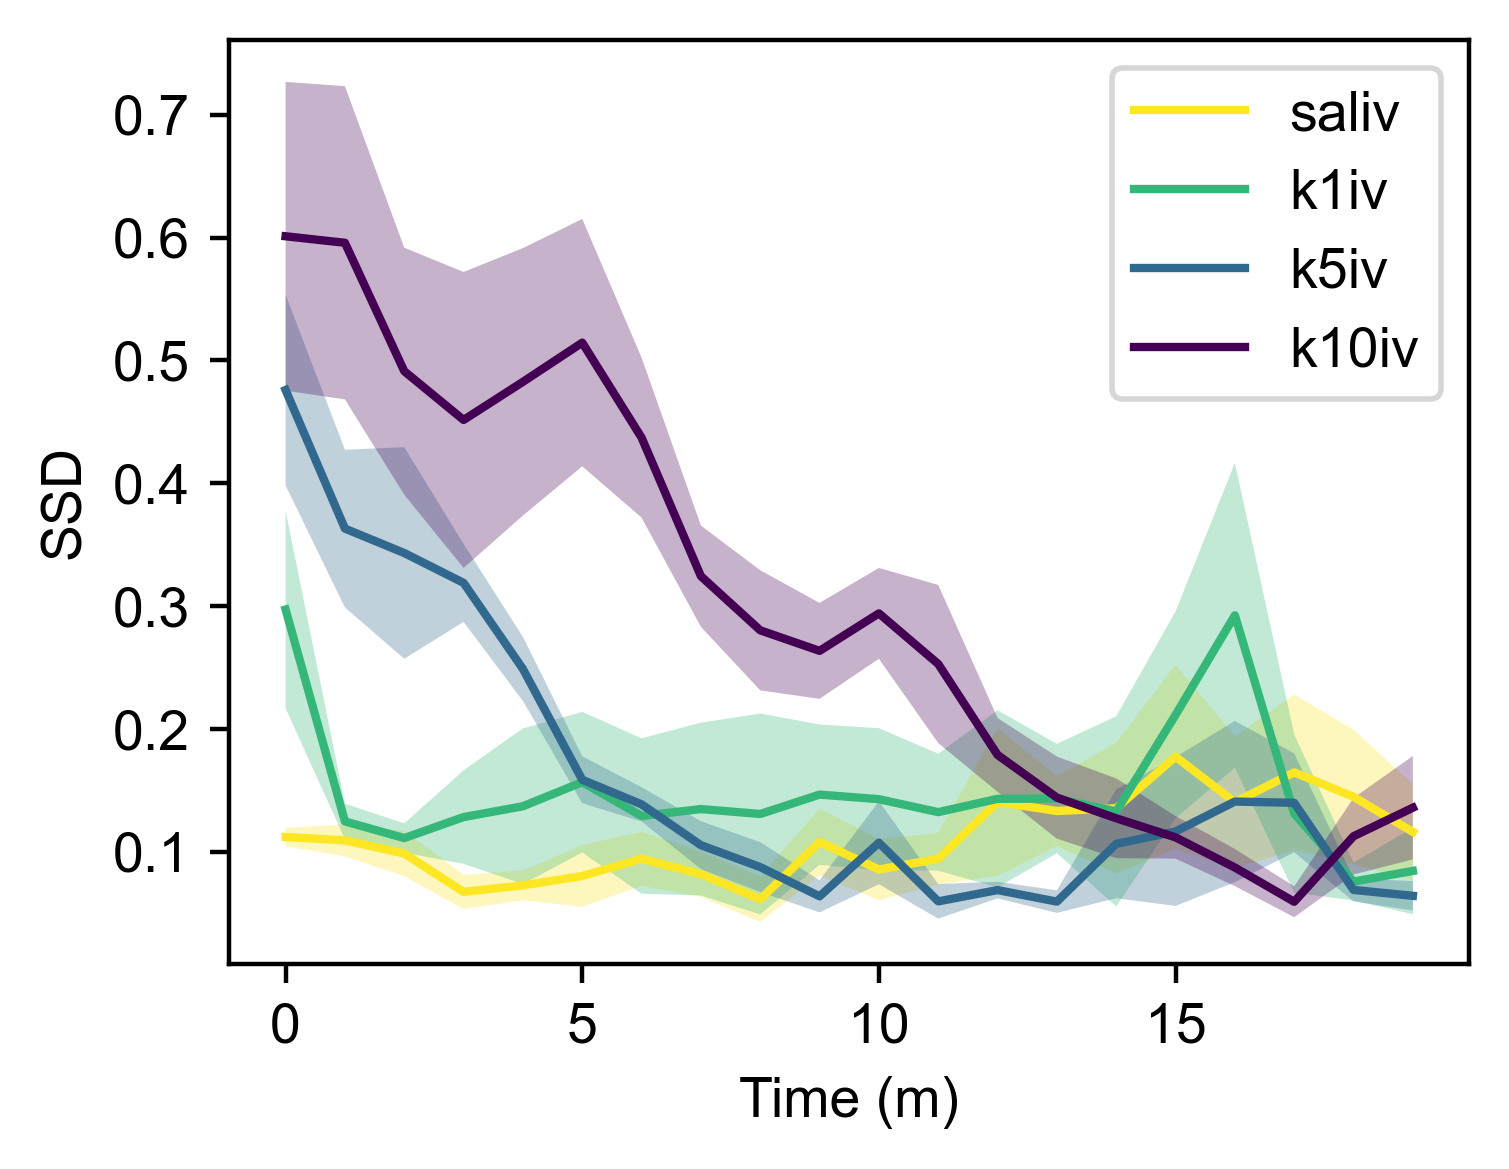

In [108]:
exp_usage_ssd = analysis.get_usage_ssd(control_usage_feats,exp_usage_feats)

plt.figure(figsize=(4,3),dpi=400)

cmap = plt.get_cmap("viridis_r")
colors = [cmap([i]) for i in np.linspace(0,1,len(selected_subgroups))]

xticks=np.float32(exp_usage_ssd.columns)/60
for g, group in enumerate(selected_subgroups):
    group_data=exp_usage_ssd.loc[config["subgroups"][group]]
    plt.plot(xticks,group_data.mean(axis=0),label=group,color=colors[g])
    plt.fill_between(np.array(xticks),np.array(group_data.mean(axis=0)-(group_data.std(axis=0)/np.sqrt(group_data.shape[0])),dtype=np.float32),
                     np.array(group_data.mean(axis=0)+(group_data.std(axis=0)/np.sqrt(group_data.shape[0])),dtype=np.float32),color=colors[g],
                     alpha=0.3,edgecolor="none")
    
plt.xlabel("Time (m)")
plt.ylabel("SSD")
plt.legend()
plt.tight_layout
if save==True:
    plt.savefig(save_path+"doseresp_pk_beh_ssd.png",dpi=500)

## Exercise 2: Routes of administration


drop


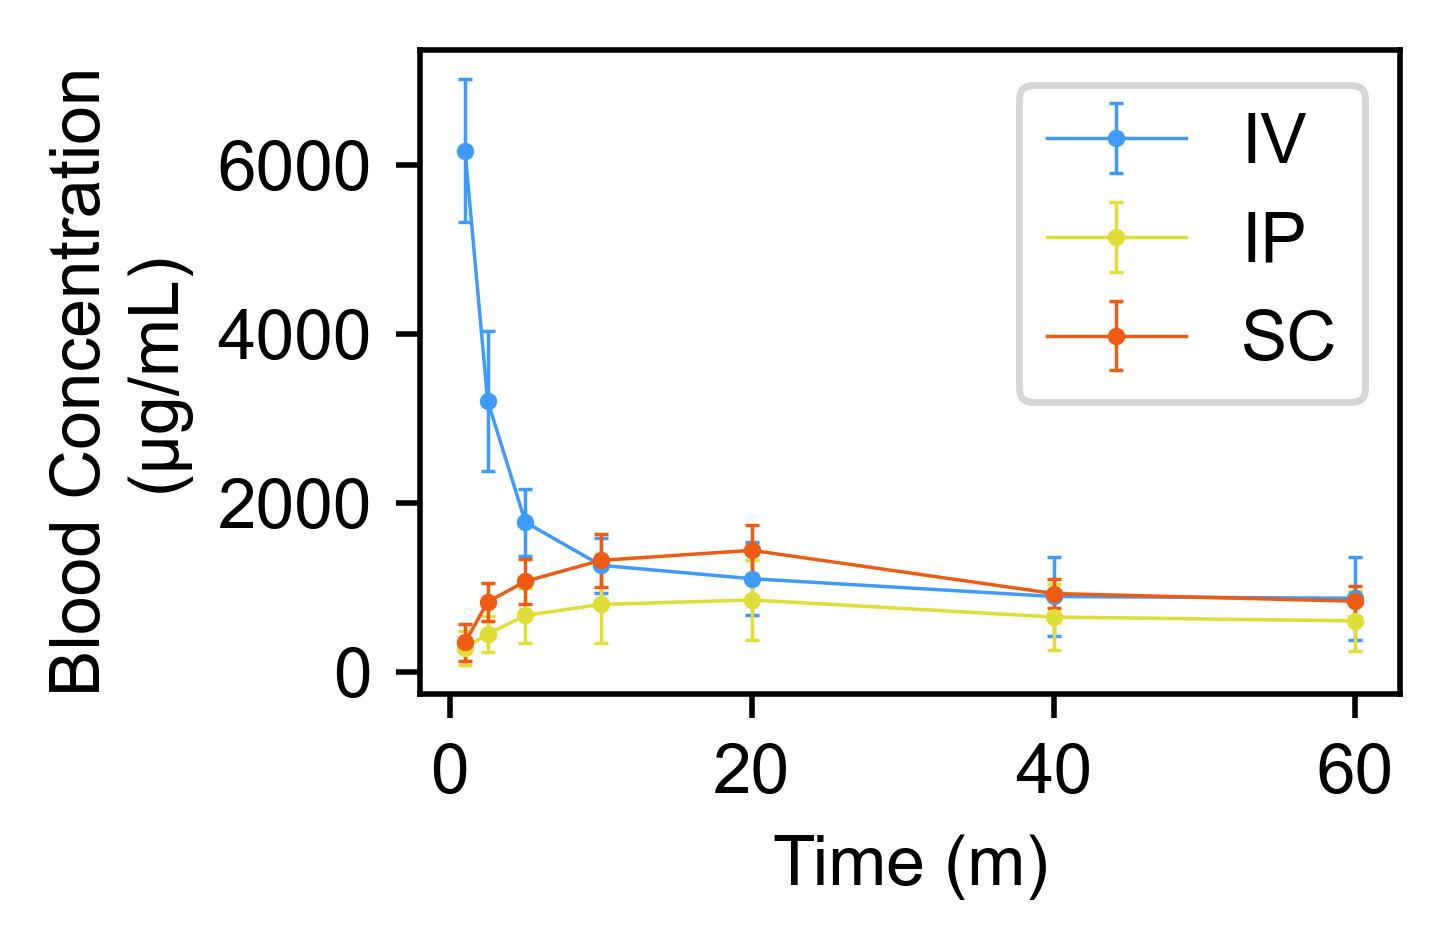

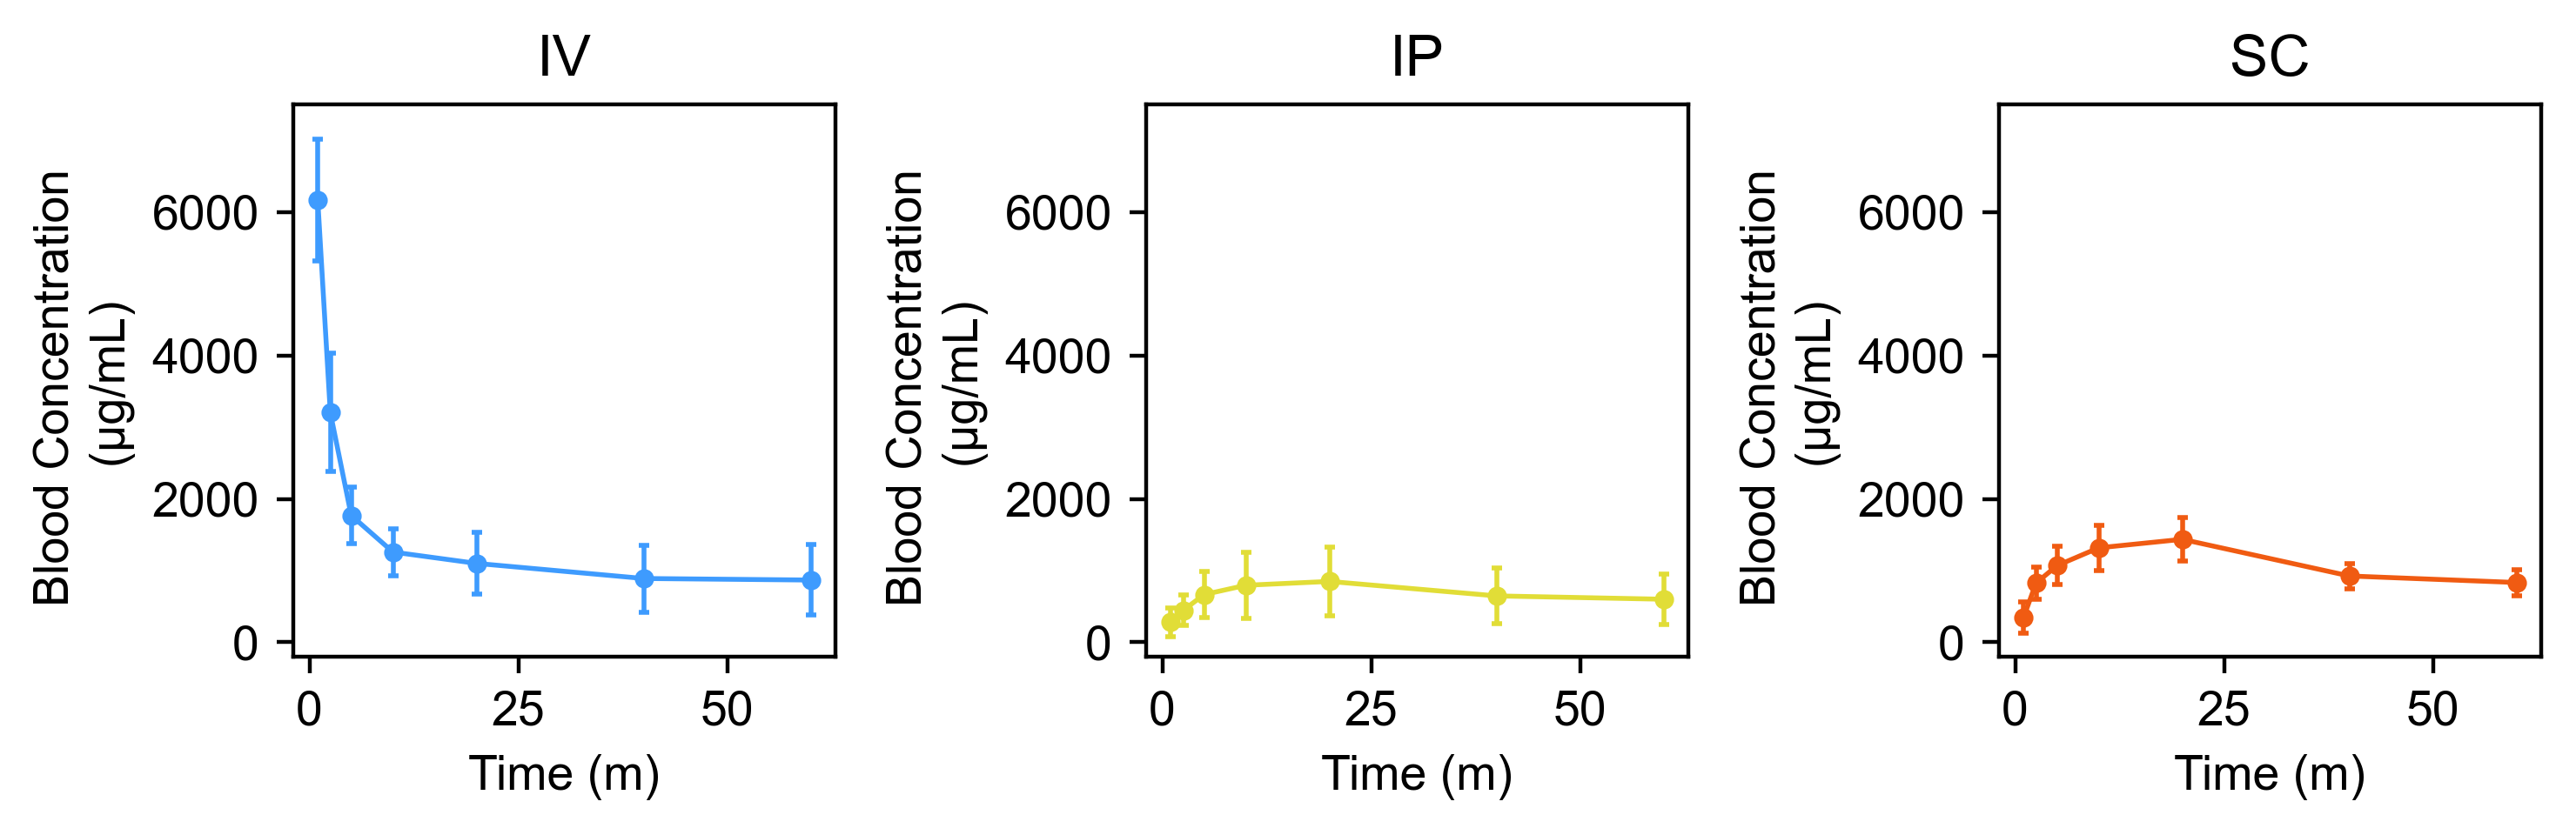

In [123]:
def load_pk(pk_path,drops=True):
    df = pd.read_csv(pk_path,index_col="Time")
    df = df.apply(pd.to_numeric, errors='coerce')
    if drops==True:
        # df.at[1.0,"R13"]=np.nan
        # df.at[1.0,"R3"]=np.nan
        # df.at[2.5,"R3"]=np.nan
        # df.at[5.0,"R3"]=np.nan
        # df.at[10.0,"R3"]=np.nan
        # df.at[20.0,"R3"]=np.nan
        # df.at[40.0,"R3"]=np.nan
        # df.at[60.0,"R3"]=np.nan
        df.at[1.0,"R13"]=np.nan
        print("drop")
    df.drop(index=62.0,inplace=True)
    return df

#Load the data
pk_path="/Users/snewbank/Documents/PhD/Data/25-02-06-bloodPKexpt-full/25-02-06_ketblood_ROAs.csv"


IV=["R1","R4","R7","R10","R13","R14","R17"]
SC=["R2","R5","R8","R11","R20"]
IP=["R3","R6","R9","R12","R15","R16","R18","R19"]

cmap=plt.get_cmap("turbo")

drops_TF=True

groups={"IV" : IV, "IP" : IP, "SC" : SC}

drops_TF=True
df = load_pk(pk_path,drops=drops_TF)

#Making the 1-panel plot
plt.figure(figsize=(3,2),dpi=500)

df=df*20

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    plt.plot()
    plt.errorbar(df.index, m, yerr=std, color=colors[k],label=key,linewidth=0.5,capsize=1,markeredgewidth=0.5,markersize=2,marker="o")
    plt.xlabel('Time (m)')
    plt.ylabel('Blood Concentration \n(μg/mL)')
    plt.legend()

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit.png",dpi=500)
    

# Making the 3-panel plot
fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    ax[k].plot()
    ax[k].errorbar(df.index, m, yerr=std, color=colors[k],linewidth=1,capsize=1,markeredgewidth=1,markersize=3,marker="o")
    ax[k].set_xlabel('Time (m)')
    ax[k].set_ylabel('Blood Concentration \n(μg/mL)')
    ax[k].set_title(key)
    ax[k].set_ylim([-200,7500])

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit_panel.png",dpi=500)

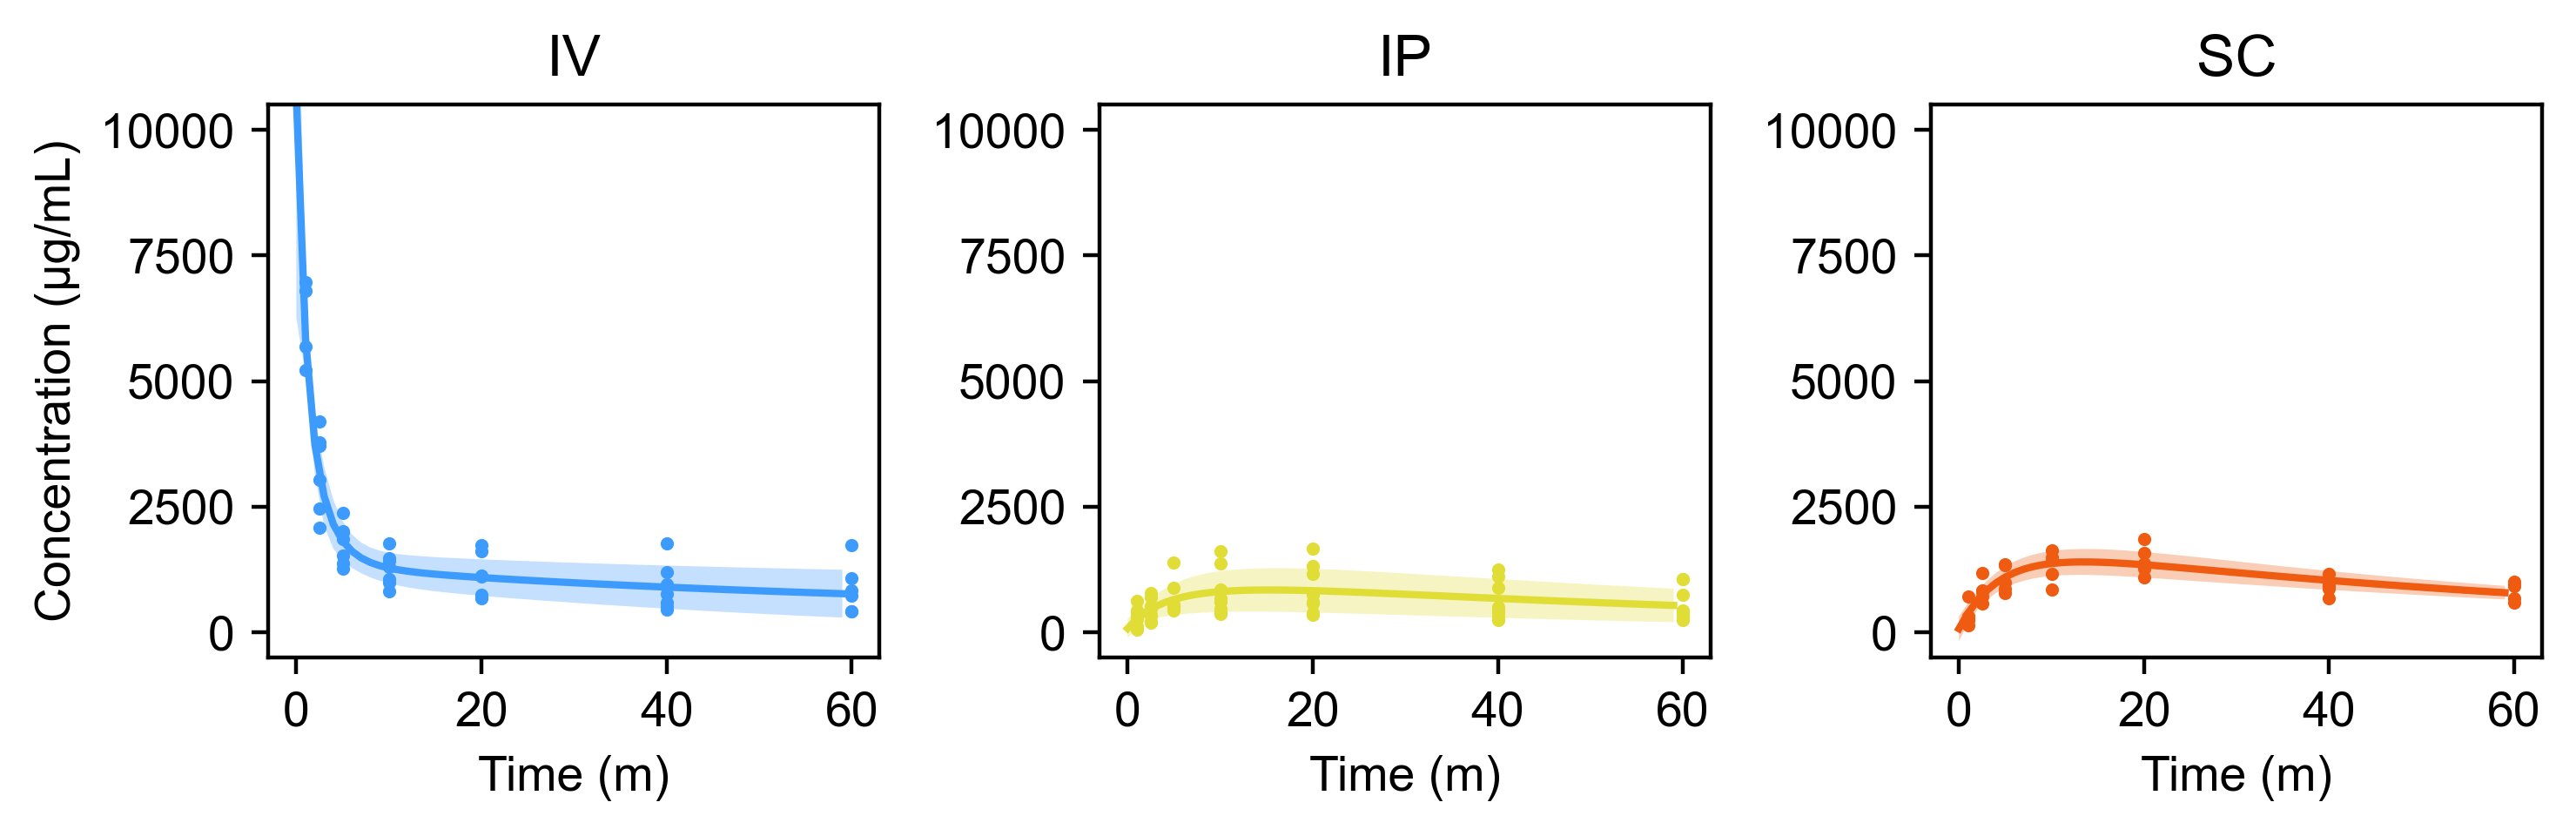

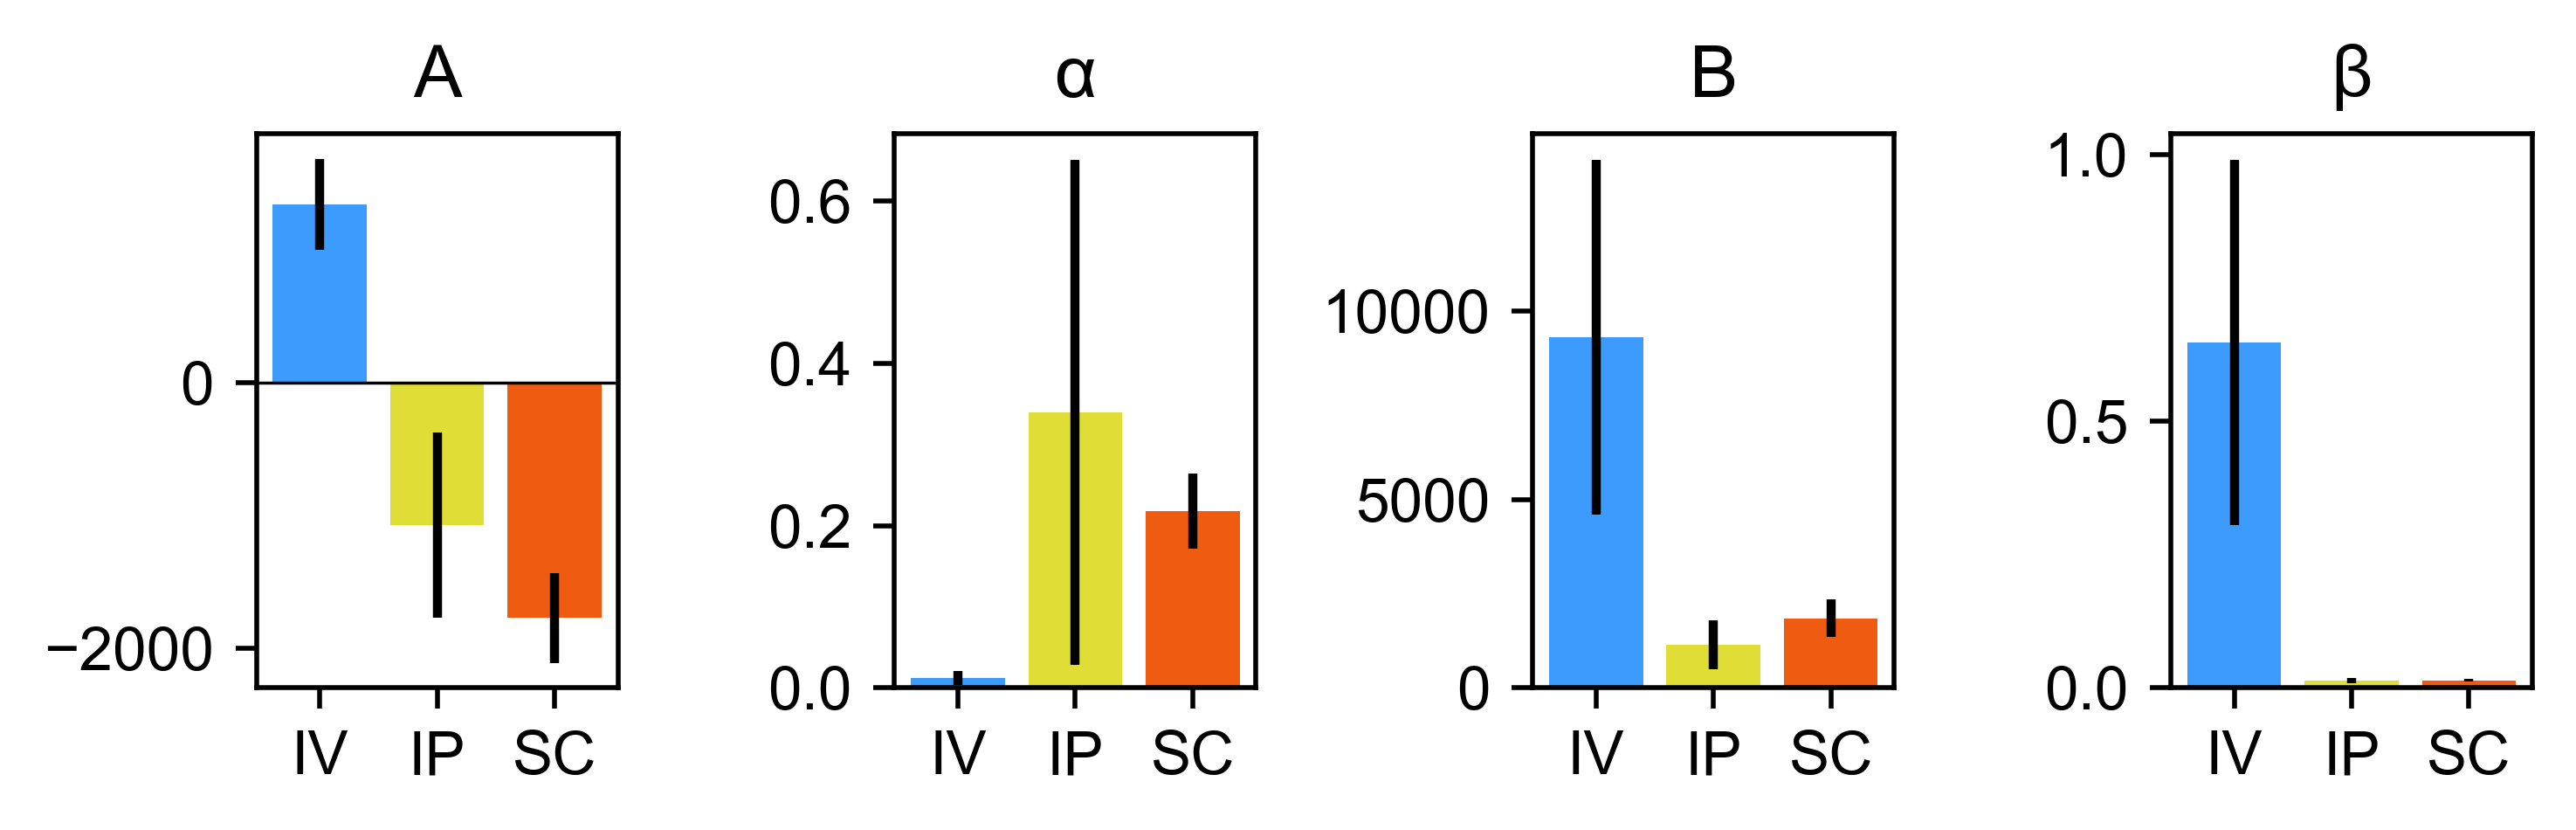

In [110]:
def biexponential(t, a, alpha, b, beta):
    return a * np.exp(-alpha * t) + b * np.exp(-beta * t)

def slope(point1, point2):
    return ((point1[1] - point2[1]) / (point1[0] - point2[0]))

def fit_to_biexponential(t,c):
    # Set initial "guess"
    p0=np.zeros(4)
    p0[0]=-10*slope([t[0],c[0]],[t[1],c[1]])
    p0[2]=-10*slope([t[np.argmax(c)],c[np.argmax(c)]],[t[-1],c[-1]])
    if np.argmax(c)!=0:
        p0[1] = 0.693/((t[np.argmax(c)]-t[0])/2)
    p0[3] = 0.693/((t[-1]-t[-2])/2)
    
    # Set bounds
    t0_to_peak=t[np.argmax(c)]
    peak_to_tlast=t[-1]-t[np.argmax(c)]
    
    bounds = ([-np.inf,0,-np.inf,0], [np.inf,t0_to_peak,np.inf,peak_to_tlast])
    
    for p,param in enumerate(p0):
        if param<bounds[0][p]:
            p0[p]=bounds[0][p]
        if param>bounds[1][p]:
            p0[p]=bounds[1][p]
    
    fit = optimize.curve_fit(biexponential, t, c, p0=p0, bounds=bounds, maxfev=10000)
    
    return fit

plot_types = ["mean_params","mean_fits"]
plot_type = plot_types[1]

groups={"IV" : IV, "IP" : IP, "SC" : SC}

cmap=plt.get_cmap("turbo")
colors={"IV": cmap([0.2]),"IP": cmap([0.6]),"SC": cmap([0.8])}

fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

all_fits=[]
for g, group in enumerate(groups.keys()):
    fits=[]
    subj=[]
    for i in range(len(df[groups[group]].columns)):
        data_i = df[groups[group]][df[groups[group]].columns[i]].dropna()
        if len(data_i)==0:
            continue
        subj.append(group+"_"+df[groups[group]].columns[i])
        t = data_i.index
        c = data_i.to_numpy()
        ax[g].scatter(t,c,color=colors[group],s=3)
        
        fit = fit_to_biexponential(t,c)
        fits.append(fit[0])
    
    if plot_type=="mean_params":
        fits=np.array(fits)
        mean_fit = np.mean(fits,axis=0)
        sd_fit = np.std(fits,axis=0)
        t=np.arange(0,60,1)
        c_fit_mean=biexponential(t,*mean_fit)
        hi_fit_mean=biexponential(t,*(mean_fit+sd_fit))
        lo_fit_mean=biexponential(t,*(mean_fit-sd_fit))
        ax[g].plot(t,c_fit_mean,color=colors[group])
        ax[g].fill_between(t,lo_fit_mean,hi_fit_mean,color=colors[group],alpha=0.3,edgecolor="none")
    elif plot_type=="mean_fits":
        t=np.arange(0,60,1)
        fit_curves=[]
        for fit in fits:
            fit_curves.append(biexponential(t,*fit))
        mean_fit = np.mean(np.array(fit_curves),axis=0)
        sd_fit = np.std(np.array(fit_curves),axis=0)
        ax[g].plot(t,mean_fit,color=colors[group])
        ax[g].fill_between(t,mean_fit-sd_fit,mean_fit+sd_fit,color=colors[group],alpha=0.3,edgecolor="none")
        fits=np.array(fits)
    ax[g].set_ylim([-500,10500])
    ax[g].set_title(group)
    ax[g].set_xlabel("Time (m)")
    ax[0].set_ylabel("Concentration (μg/mL)")
    
    all_fits.append(pd.DataFrame({"A":fits[:,0],"α":fits[:,1],"B":fits[:,2],"β":fits[:,3]},index=subj))
plt.tight_layout()
fit_df = pd.concat(all_fits)
if save==True:
    plt.savefig(save_path+"roa_pk_blood_fits.png",dpi=500)

fig, ax = plt.subplots(1,4,figsize=(6,2),dpi=500)

ticks=[]
labels=[]

for g, group in enumerate(groups.keys()):
    inds=[i for i in fit_df.index if i.startswith(group)]
    sub_df=fit_df.loc[inds]
    ticks.append(g)
    labels.append(group)
    for c,coeff in enumerate(fit_df.columns):
        mean=sub_df[coeff].mean()
        std=sub_df[coeff].std()
        ax[c].bar(x=g,height=mean,color=colors[group])
        ax[c].errorbar(g,mean,yerr=std,color="black")
        ax[c].set_title(coeff)

for c in range(len(fit_df.columns)):
    ax[c].set_xticks(ticks)
    ax[c].set_xticklabels(labels)
    ax[c].axhline(0,color="black",linewidth=0.5)
plt.tight_layout()
if save==True:
    plt.savefig(save_path+"roa_pk_blood_fit_params.png",dpi=500)

drop


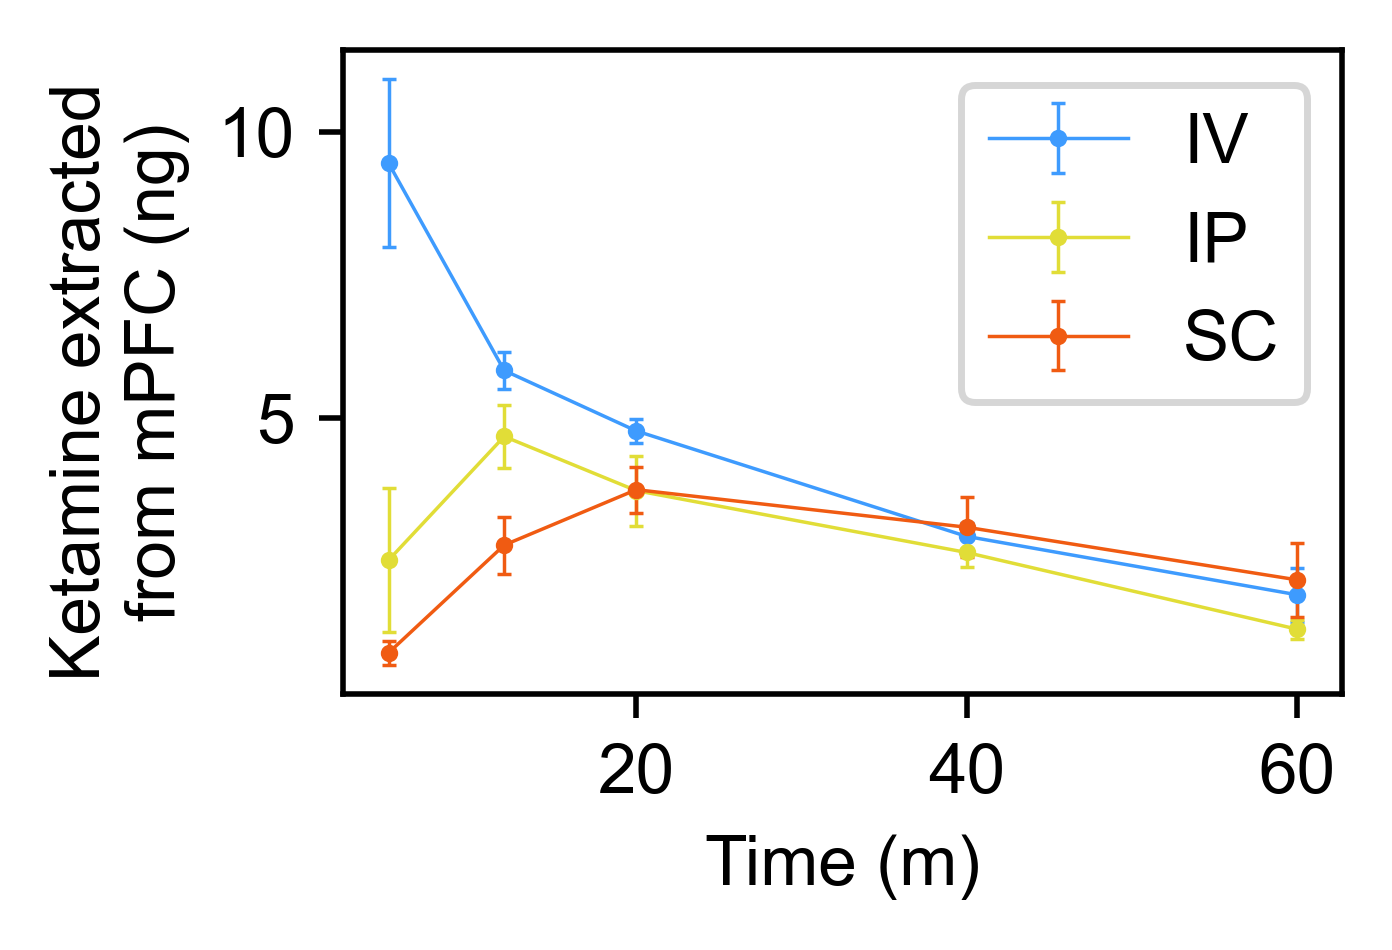

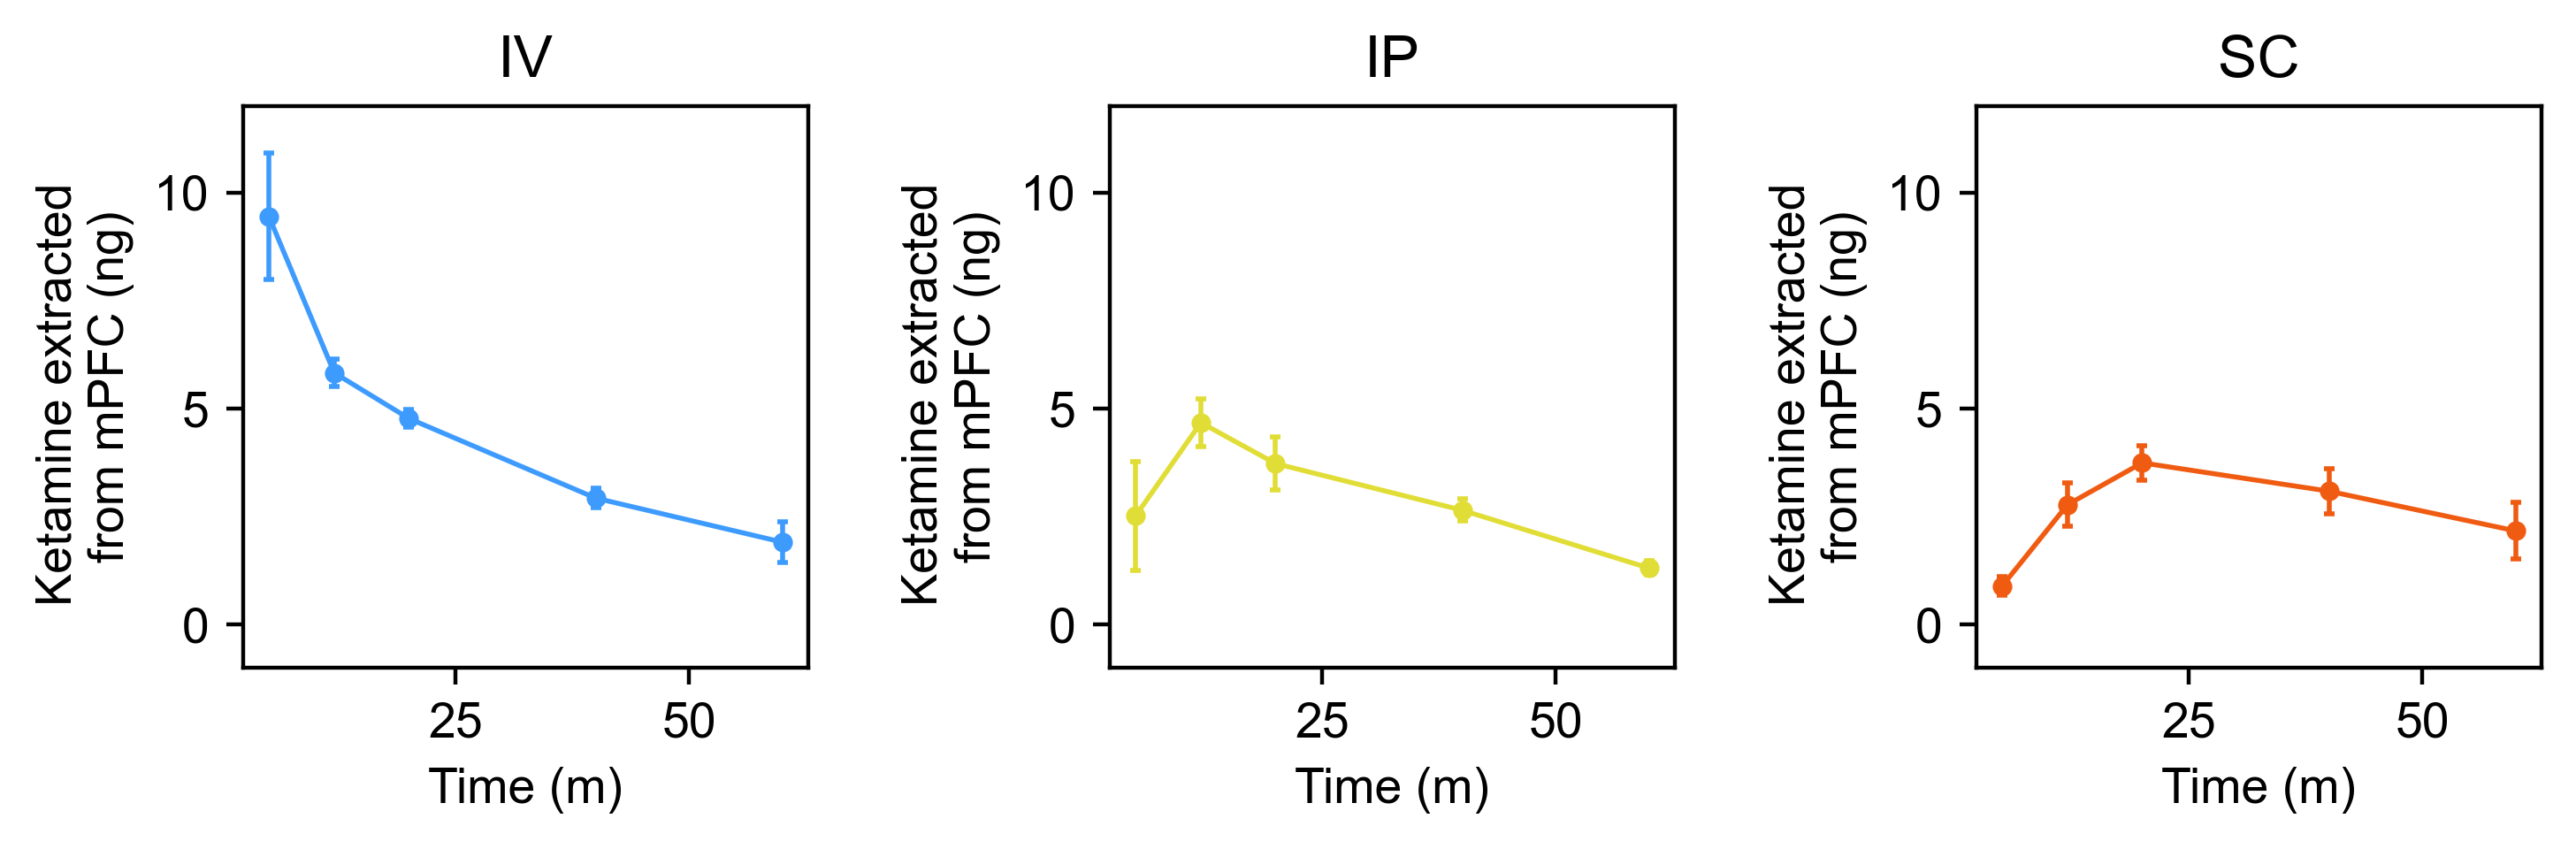

In [111]:
def load_pk(pk_path,drops=True):
    df = pd.read_csv(pk_path,index_col="Time")
    df = df.apply(pd.to_numeric, errors='coerce')
    if drops==True:
        # df.at[1.0,"R13"]=np.nan
        # df.at[1.0,"R3"]=np.nan
        # df.at[2.5,"R3"]=np.nan
        # df.at[5.0,"R3"]=np.nan
        # df.at[10.0,"R3"]=np.nan
        # df.at[20.0,"R3"]=np.nan
        # df.at[40.0,"R3"]=np.nan
        # df.at[60.0,"R3"]=np.nan
        #df.at[1.0,"R13"]=np.nan
        print("drop")
        #df.drop(index=62.0,inplace=True)
    return df

#Load the data
pk_path="/Users/snewbank/Documents/PhD/Data/25-03-16_brain_pk_ROAs.csv"

IV=["R1","R3","R5","R7"]
IP=["R6","R8","R10","R12"]
SC=["R2","R4","R9","R11"]

cmap=plt.get_cmap("turbo")

drops_TF=True

groups={"IV" : IV, "IP" : IP, "SC" : SC}

drops_TF=True
df = load_pk(pk_path,drops=drops_TF)

#Making the 1-panel plot
plt.figure(figsize=(3,2),dpi=500)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    plt.plot()
    plt.errorbar(df.index, m, yerr=std, color=colors[k],label=key,linewidth=0.5,capsize=1,markeredgewidth=0.5,markersize=2,marker="o")
    plt.xlabel('Time (m)')
    plt.ylabel('Ketamine extracted \nfrom mPFC (ng)')
    plt.legend()

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_brain_no_fit.png",dpi=500)
    

# Making the 3-panel plot
fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    ax[k].plot()
    ax[k].errorbar(df.index, m, yerr=std, color=colors[k],linewidth=1,capsize=1,markeredgewidth=1,markersize=3,marker="o")
    ax[k].set_xlabel('Time (m)')
    ax[k].set_ylabel('Ketamine extracted \nfrom mPFC (ng)')
    ax[k].set_title(key)
    ax[k].set_ylim([-1,12])

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_brain_no_fit_panel.png",dpi=500)

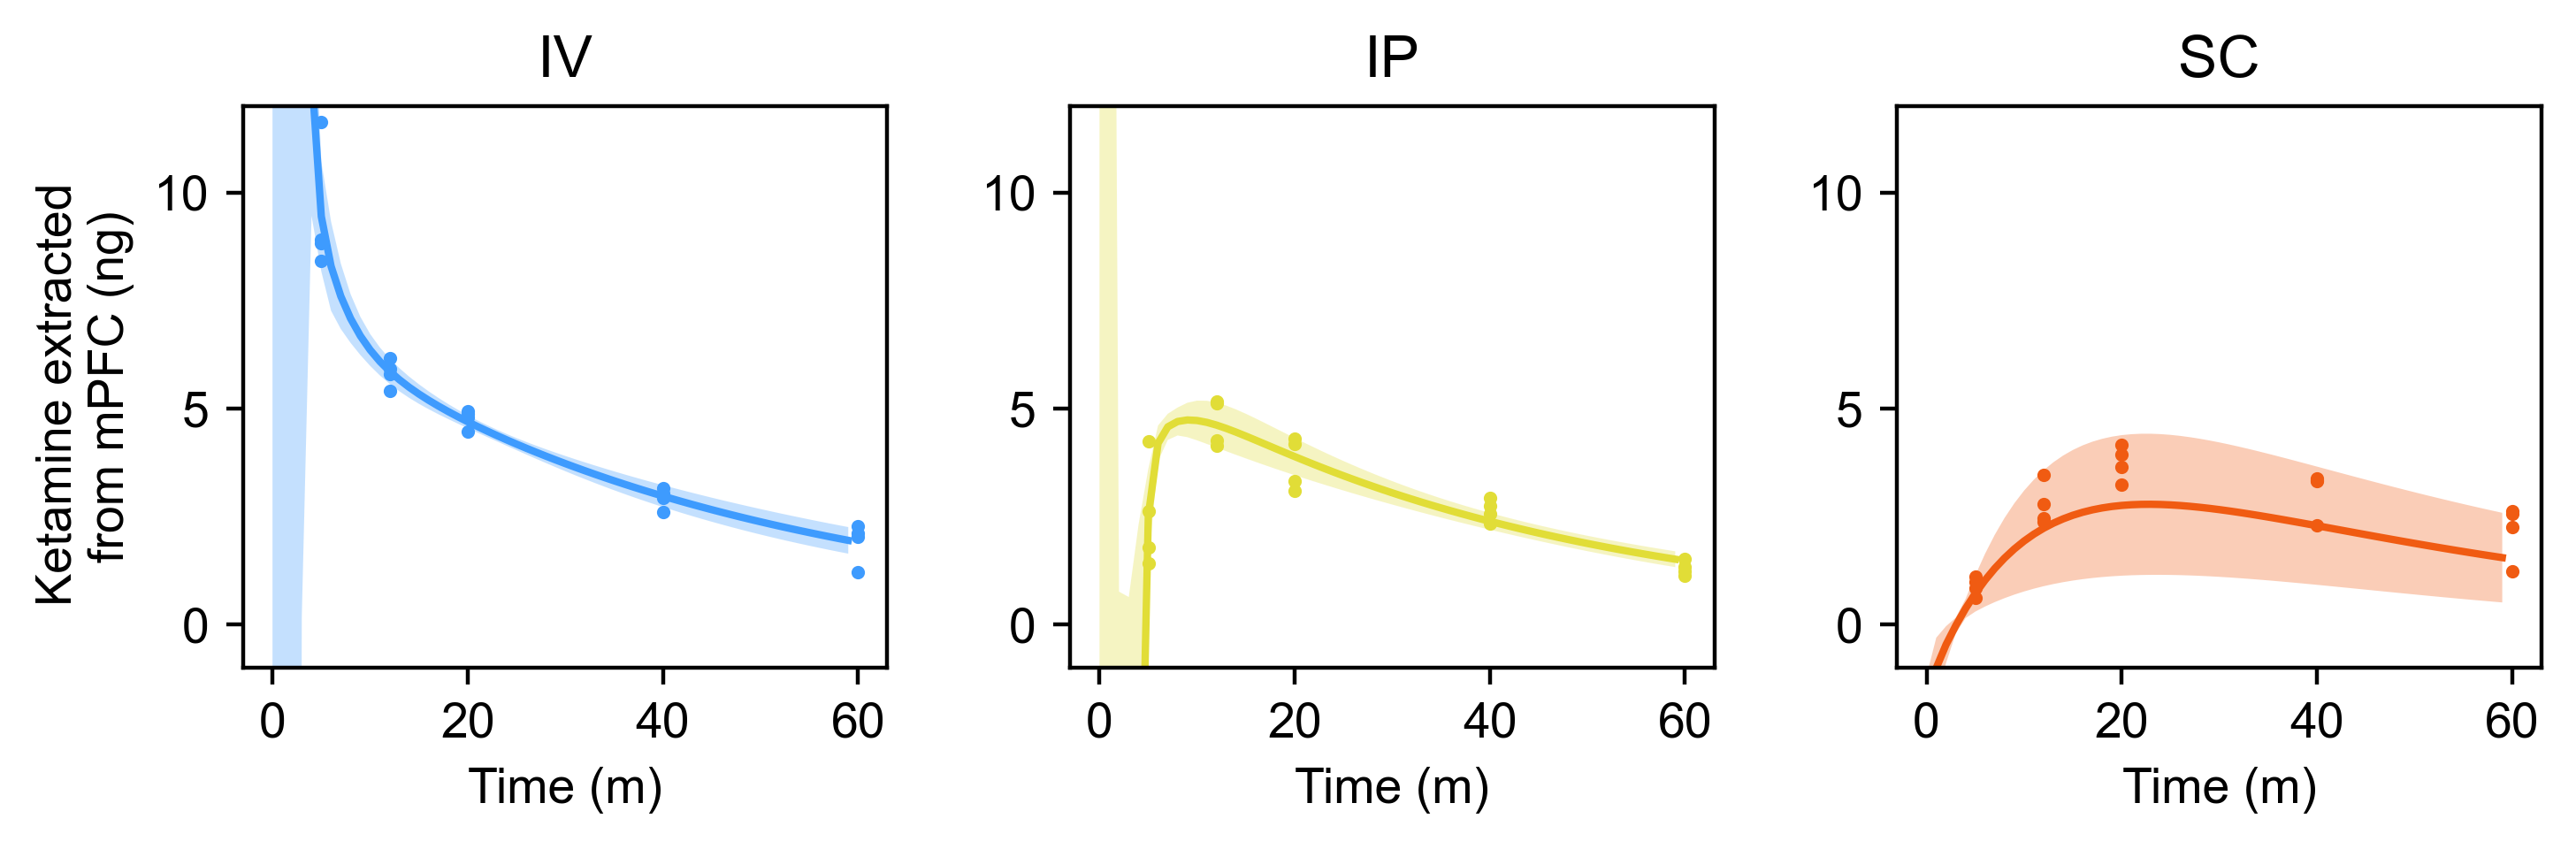

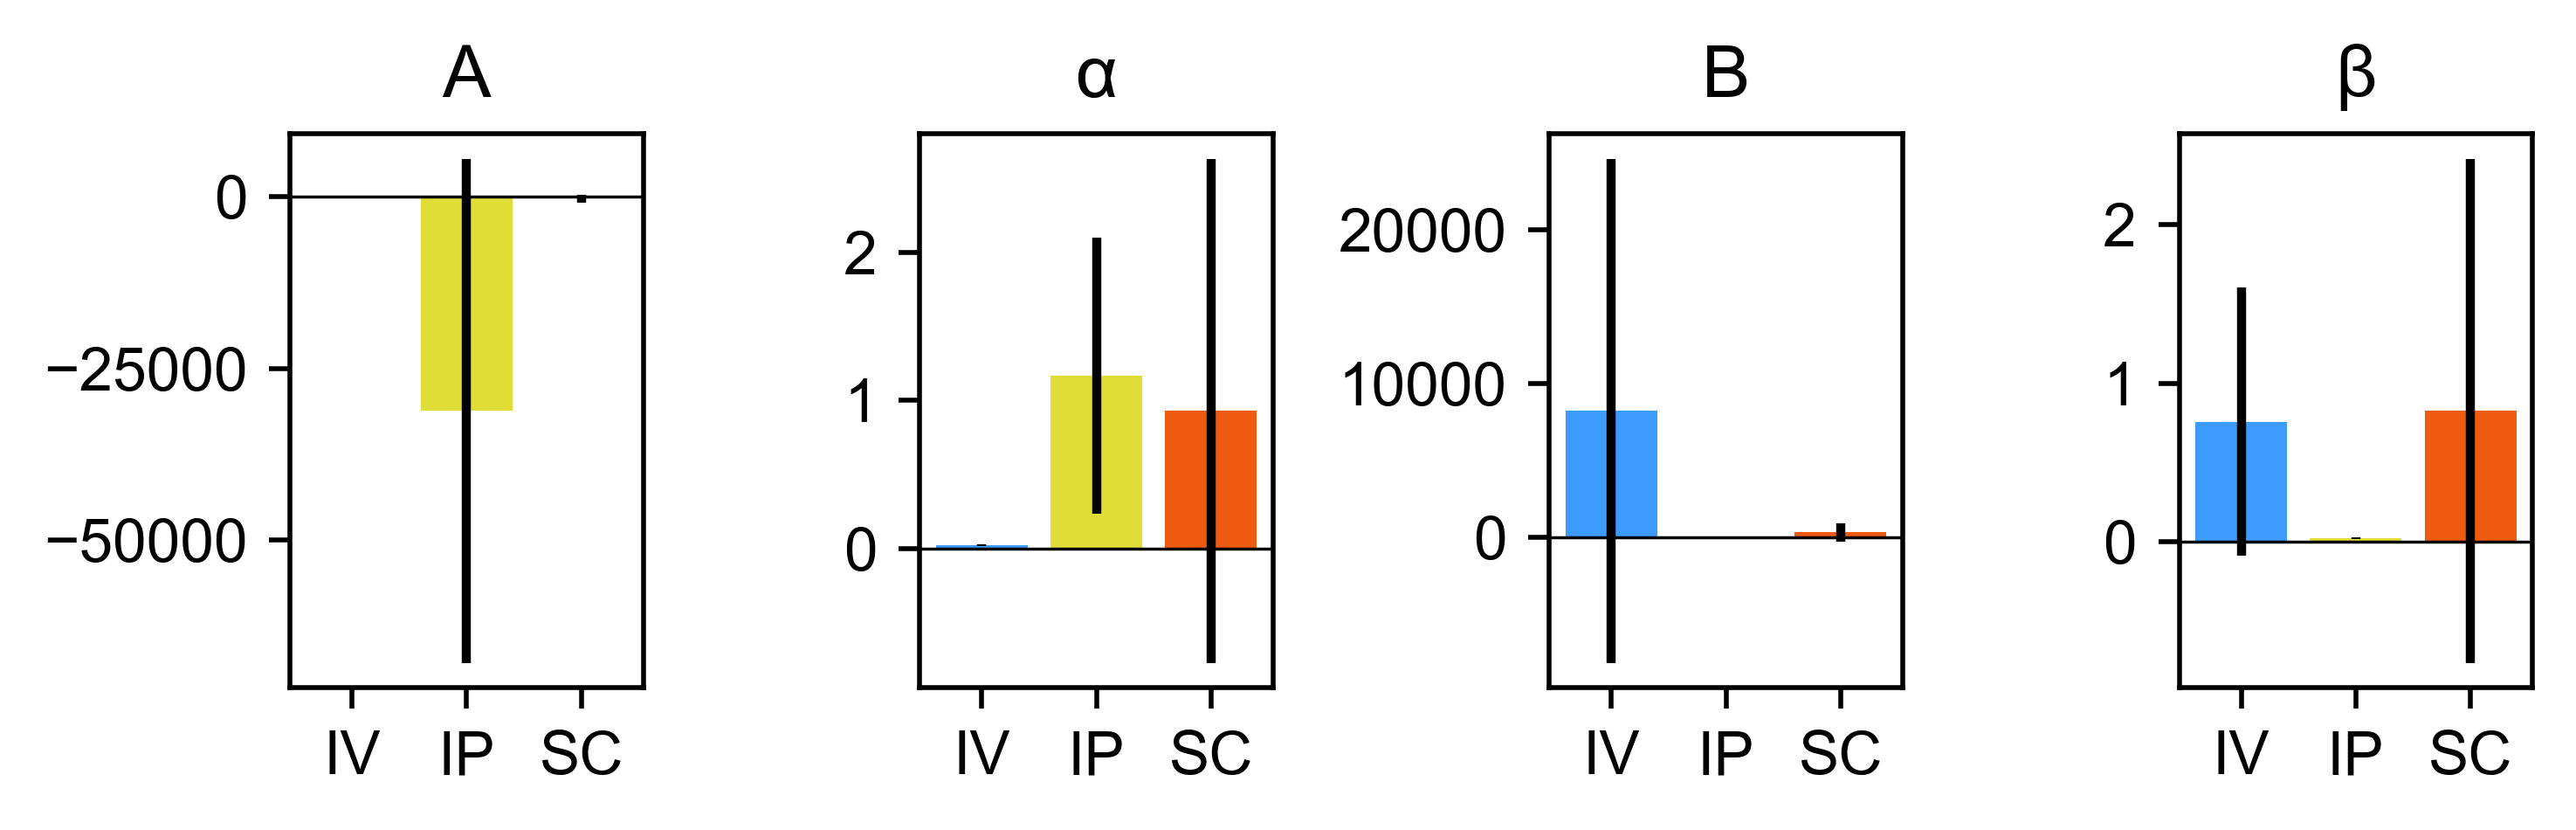

In [112]:
def biexponential(t, a, alpha, b, beta):
    return a * np.exp(-alpha * t) + b * np.exp(-beta * t)

def slope(point1, point2):
    return ((point1[1] - point2[1]) / (point1[0] - point2[0]))

def fit_to_biexponential(t,c):
    # Set initial "guess"
    p0=np.zeros(4)
    p0[0]=-10*slope([t[0],c[0]],[t[1],c[1]])
    p0[2]=-10*slope([t[np.argmax(c)],c[np.argmax(c)]],[t[-1],c[-1]])
    if np.argmax(c)!=0:
        p0[1] = 0.693/((t[np.argmax(c)]-t[0])/2)
    p0[3] = 0.693/((t[-1]-t[-2])/2)
    
    # Set bounds
    t0_to_peak=t[np.argmax(c)]
    peak_to_tlast=t[-1]-t[np.argmax(c)]
    
    bounds = ([-np.inf,0,-np.inf,0], [np.inf,t0_to_peak,np.inf,peak_to_tlast])
    
    for p,param in enumerate(p0):
        if param<bounds[0][p]:
            p0[p]=bounds[0][p]
        if param>bounds[1][p]:
            p0[p]=bounds[1][p]
    
    fit = optimize.curve_fit(biexponential, t, c, p0=p0, bounds=bounds, maxfev=10000)
    
    return fit

plot_types = ["mean_params","mean_fits"]
plot_type = plot_types[1]

groups={"IV" : IV, "IP" : IP, "SC" : SC}

cmap=plt.get_cmap("turbo")
colors={"IV": cmap([0.2]),"IP": cmap([0.6]),"SC": cmap([0.8])}

fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

all_fits=[]
for g, group in enumerate(groups.keys()):
    fits=[]
    subj=[]
    for i in range(len(df[groups[group]].columns)):
        data_i = df[groups[group]][df[groups[group]].columns[i]].dropna()
        if len(data_i)==0:
            continue
        subj.append(group+"_"+df[groups[group]].columns[i])
        t = data_i.index
        c = data_i.to_numpy()
        ax[g].scatter(t,c,color=colors[group],s=3)
        
        fit = fit_to_biexponential(t,c)
        fits.append(fit[0])
    
    if plot_type=="mean_params":
        fits=np.array(fits)
        mean_fit = np.mean(fits,axis=0)
        sd_fit = np.std(fits,axis=0)
        t=np.arange(0,60,1)
        c_fit_mean=biexponential(t,*mean_fit)
        hi_fit_mean=biexponential(t,*(mean_fit+sd_fit))
        lo_fit_mean=biexponential(t,*(mean_fit-sd_fit))
        ax[g].plot(t,c_fit_mean,color=colors[group])
        ax[g].fill_between(t,lo_fit_mean,hi_fit_mean,color=colors[group],alpha=0.3,edgecolor="none")
    elif plot_type=="mean_fits":
        t=np.arange(0,60,1)
        fit_curves=[]
        for fit in fits:
            fit_curves.append(biexponential(t,*fit))
        mean_fit = np.mean(np.array(fit_curves),axis=0)
        sd_fit = np.std(np.array(fit_curves),axis=0)
        ax[g].plot(t,mean_fit,color=colors[group])
        ax[g].fill_between(t,mean_fit-sd_fit,mean_fit+sd_fit,color=colors[group],alpha=0.3,edgecolor="none")
        fits=np.array(fits)
    ax[g].set_ylim([-1,12])
    ax[g].set_title(group)
    ax[g].set_xlabel("Time (m)")
    ax[0].set_ylabel('Ketamine extracted \nfrom mPFC (ng)')
    
    all_fits.append(pd.DataFrame({"A":fits[:,0],"α":fits[:,1],"B":fits[:,2],"β":fits[:,3]},index=subj))
plt.tight_layout()
fit_df = pd.concat(all_fits)
if save==True:
    plt.savefig(save_path+"roa_pk_brain_fits.png",dpi=500)

fig, ax = plt.subplots(1,4,figsize=(6,2),dpi=500)

ticks=[]
labels=[]

for g, group in enumerate(groups.keys()):
    inds=[i for i in fit_df.index if i.startswith(group)]
    sub_df=fit_df.loc[inds]
    ticks.append(g)
    labels.append(group)
    for c,coeff in enumerate(fit_df.columns):
        mean=sub_df[coeff].mean()
        std=sub_df[coeff].std()
        ax[c].bar(x=g,height=mean,color=colors[group])
        ax[c].errorbar(g,mean,yerr=std,color="black")
        ax[c].set_title(coeff)

for c in range(len(fit_df.columns)):
    ax[c].set_xticks(ticks)
    ax[c].set_xticklabels(labels)
    ax[c].axhline(0,color="black",linewidth=0.5)
plt.tight_layout()
if save==True:
    plt.savefig(save_path+"roa_pk_brain_fit_params.png",dpi=500)

drop


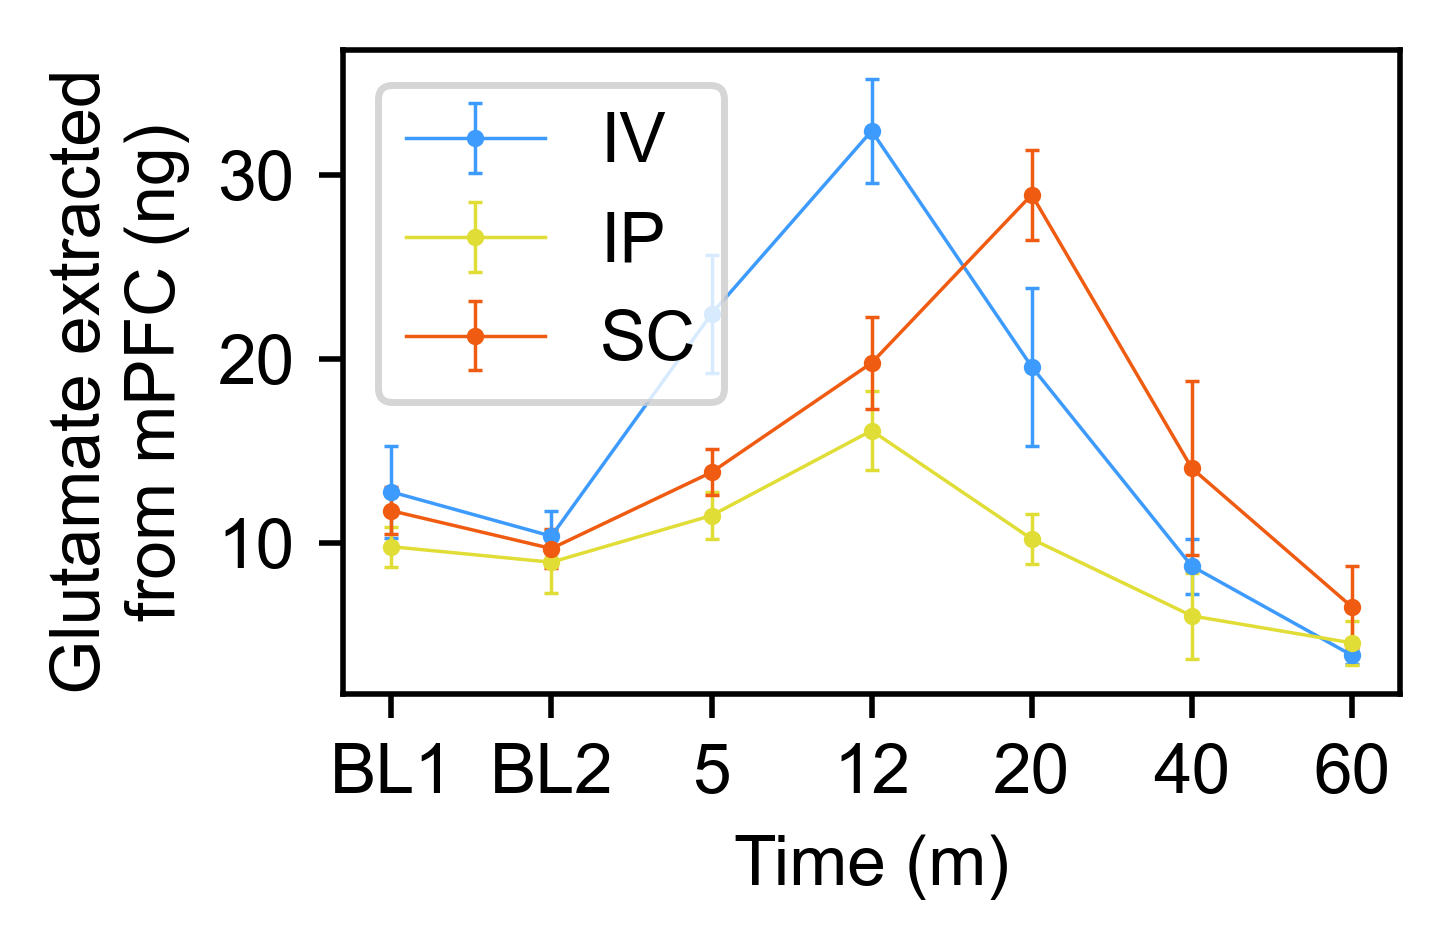

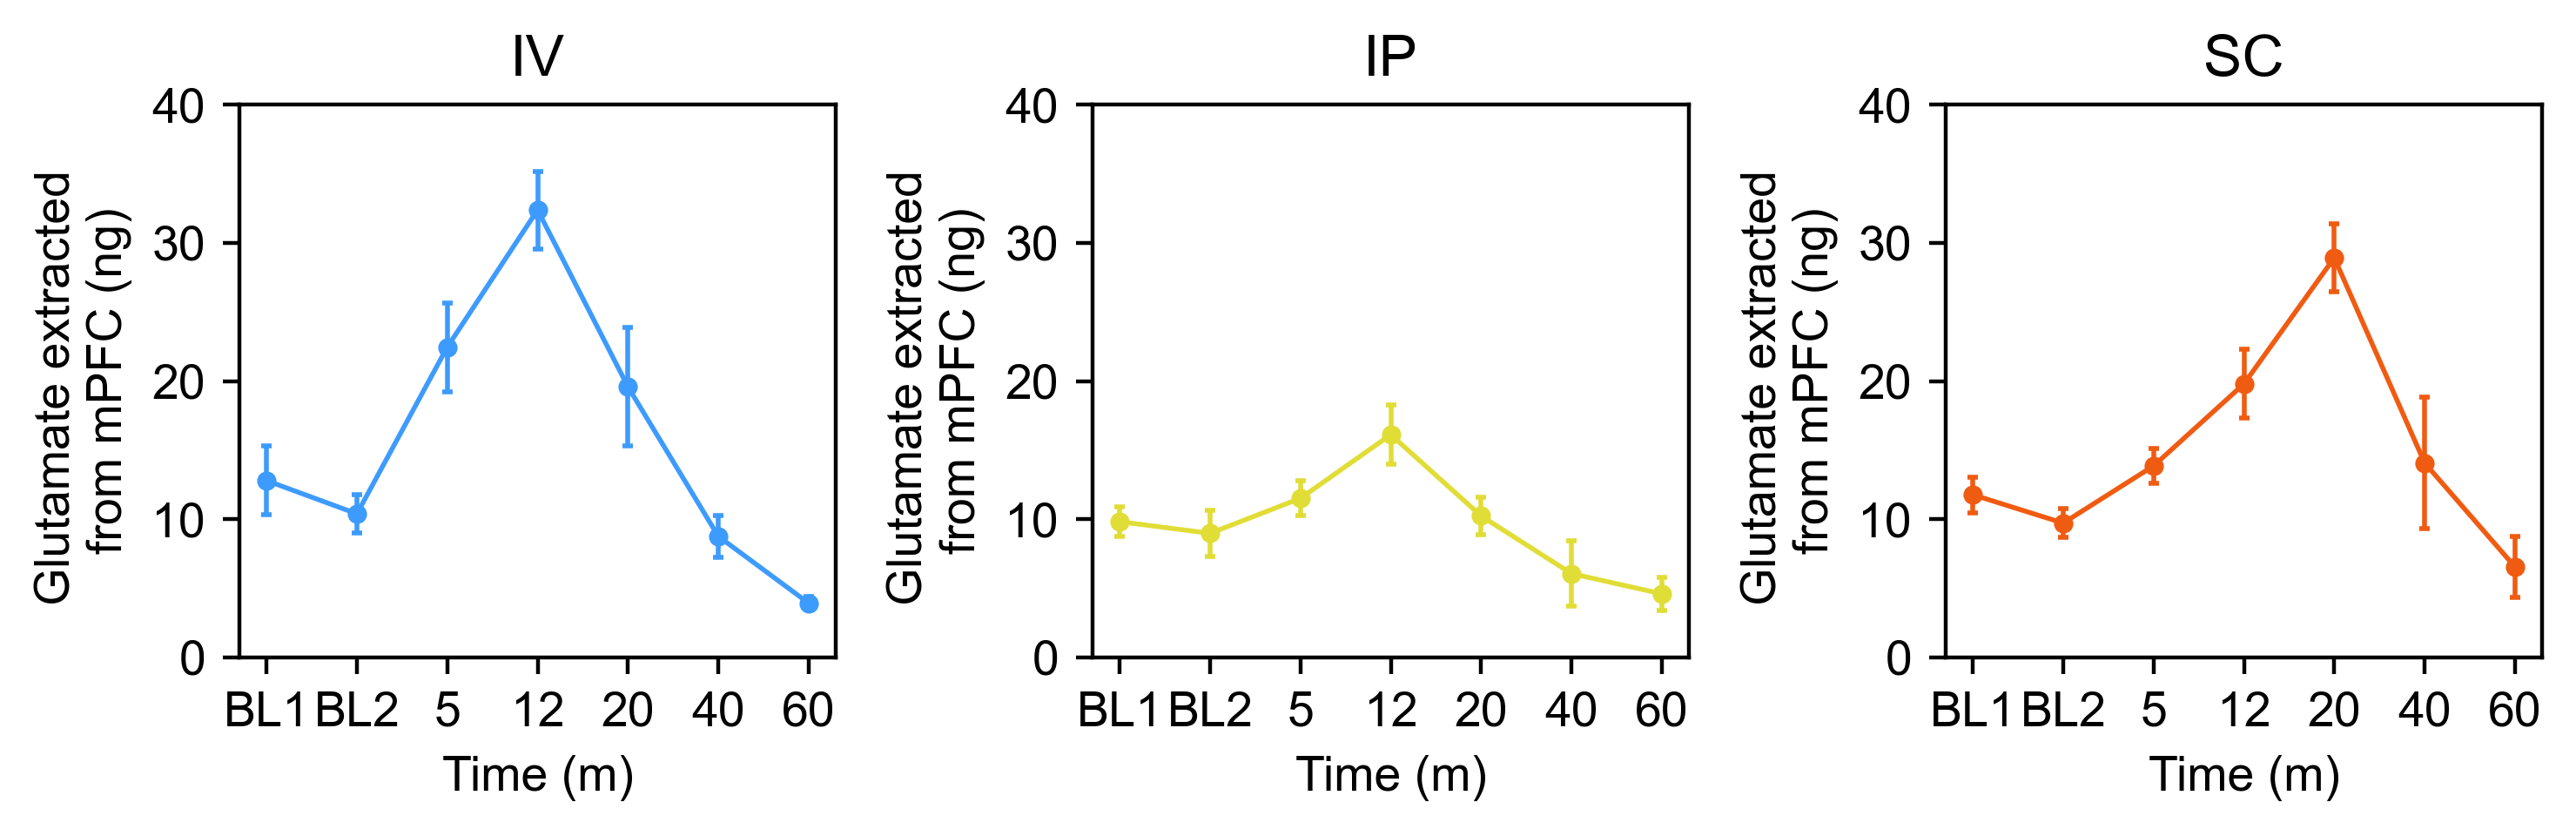

In [113]:
def load_pk(pk_path,drops=True):
    df = pd.read_csv(pk_path,index_col="Time")
    df = df.apply(pd.to_numeric, errors='coerce')
    if drops==True:
        # df.at[1.0,"R13"]=np.nan
        # df.at[1.0,"R3"]=np.nan
        # df.at[2.5,"R3"]=np.nan
        # df.at[5.0,"R3"]=np.nan
        # df.at[10.0,"R3"]=np.nan
        # df.at[20.0,"R3"]=np.nan
        # df.at[40.0,"R3"]=np.nan
        # df.at[60.0,"R3"]=np.nan
        #df.at[1.0,"R13"]=np.nan
        print("drop")
        #df.drop(index=62.0,inplace=True)
    return df

#Load the data
pk_path="/Users/snewbank/Documents/PhD/Data/25-03-16-glutamatebrainpk_withbaselines.csv"

IV=["R1","R3","R5","R7"]
IP=["R6","R8","R10","R12"]
SC=["R2","R4","R9","R11"]

cmap=plt.get_cmap("turbo")

drops_TF=True

groups={"IV" : IV, "IP" : IP, "SC" : SC}

drops_TF=True
df = load_pk(pk_path,drops=drops_TF)

#Making the 1-panel plot
plt.figure(figsize=(3,2),dpi=500)

df=df

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    plt.plot()
    plt.errorbar(df.index, m, yerr=std, color=colors[k],label=key,linewidth=0.5,capsize=1,markeredgewidth=0.5,markersize=2,marker="o")
    plt.xlabel('Time (m)')
    plt.ylabel('Glutamate extracted \nfrom mPFC (ng)')
    plt.legend()

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit_glutamate.png",dpi=500)
    

# Making the 3-panel plot
fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    ax[k].plot()
    ax[k].errorbar(df.index, m, yerr=std, color=colors[k],linewidth=1,capsize=1,markeredgewidth=1,markersize=3,marker="o")
    ax[k].set_xlabel('Time (m)')
    ax[k].set_ylabel('Glutamate extracted \nfrom mPFC (ng)')
    ax[k].set_title(key)
    ax[k].set_ylim([0,40])

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit_panel_glutamate.png",dpi=500)

drop


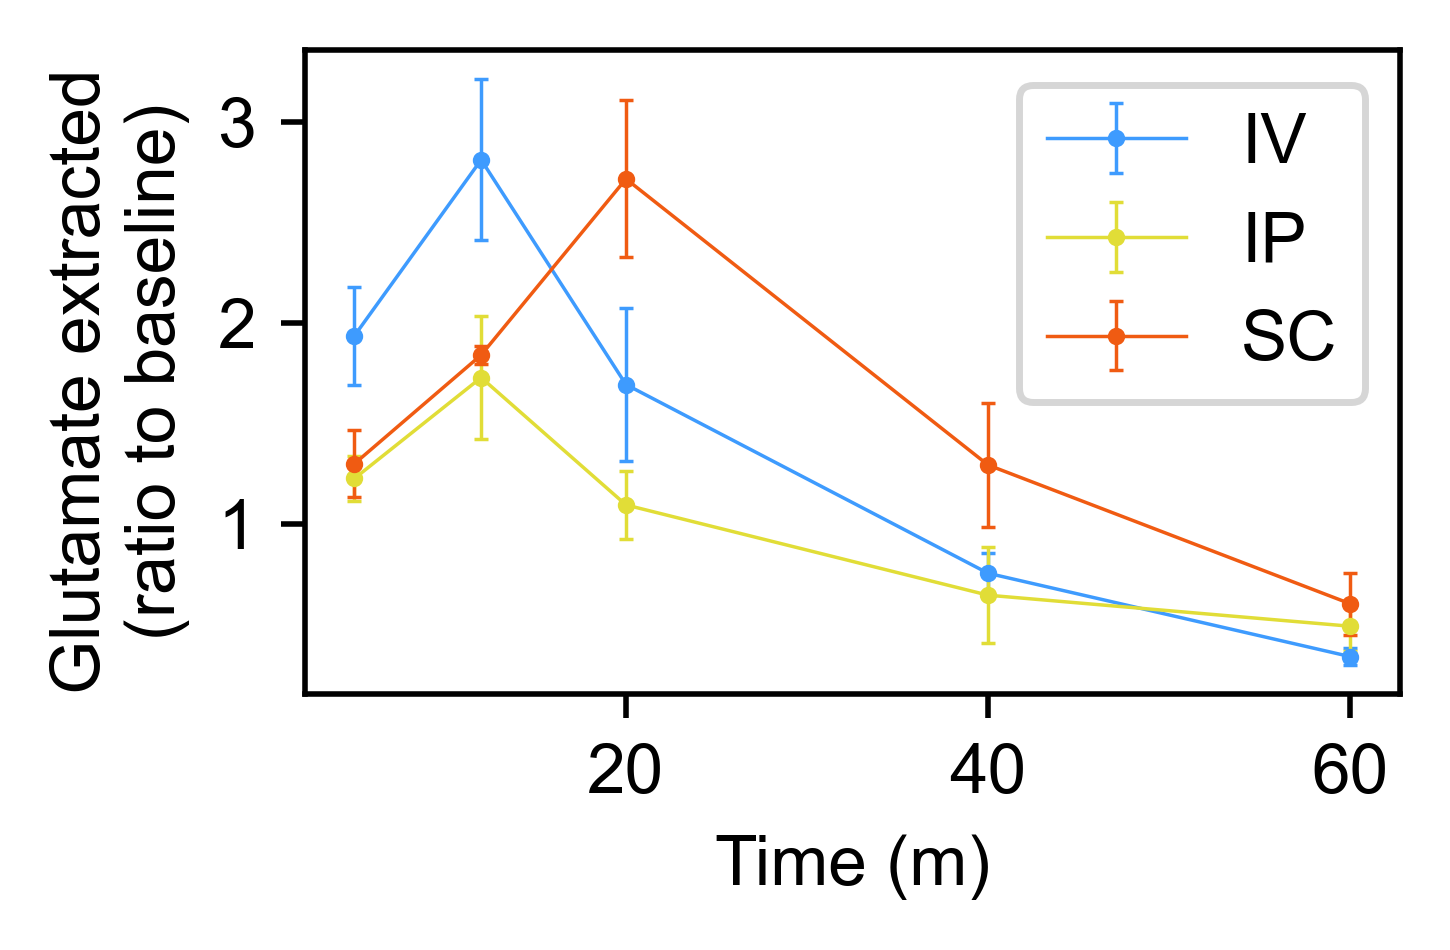

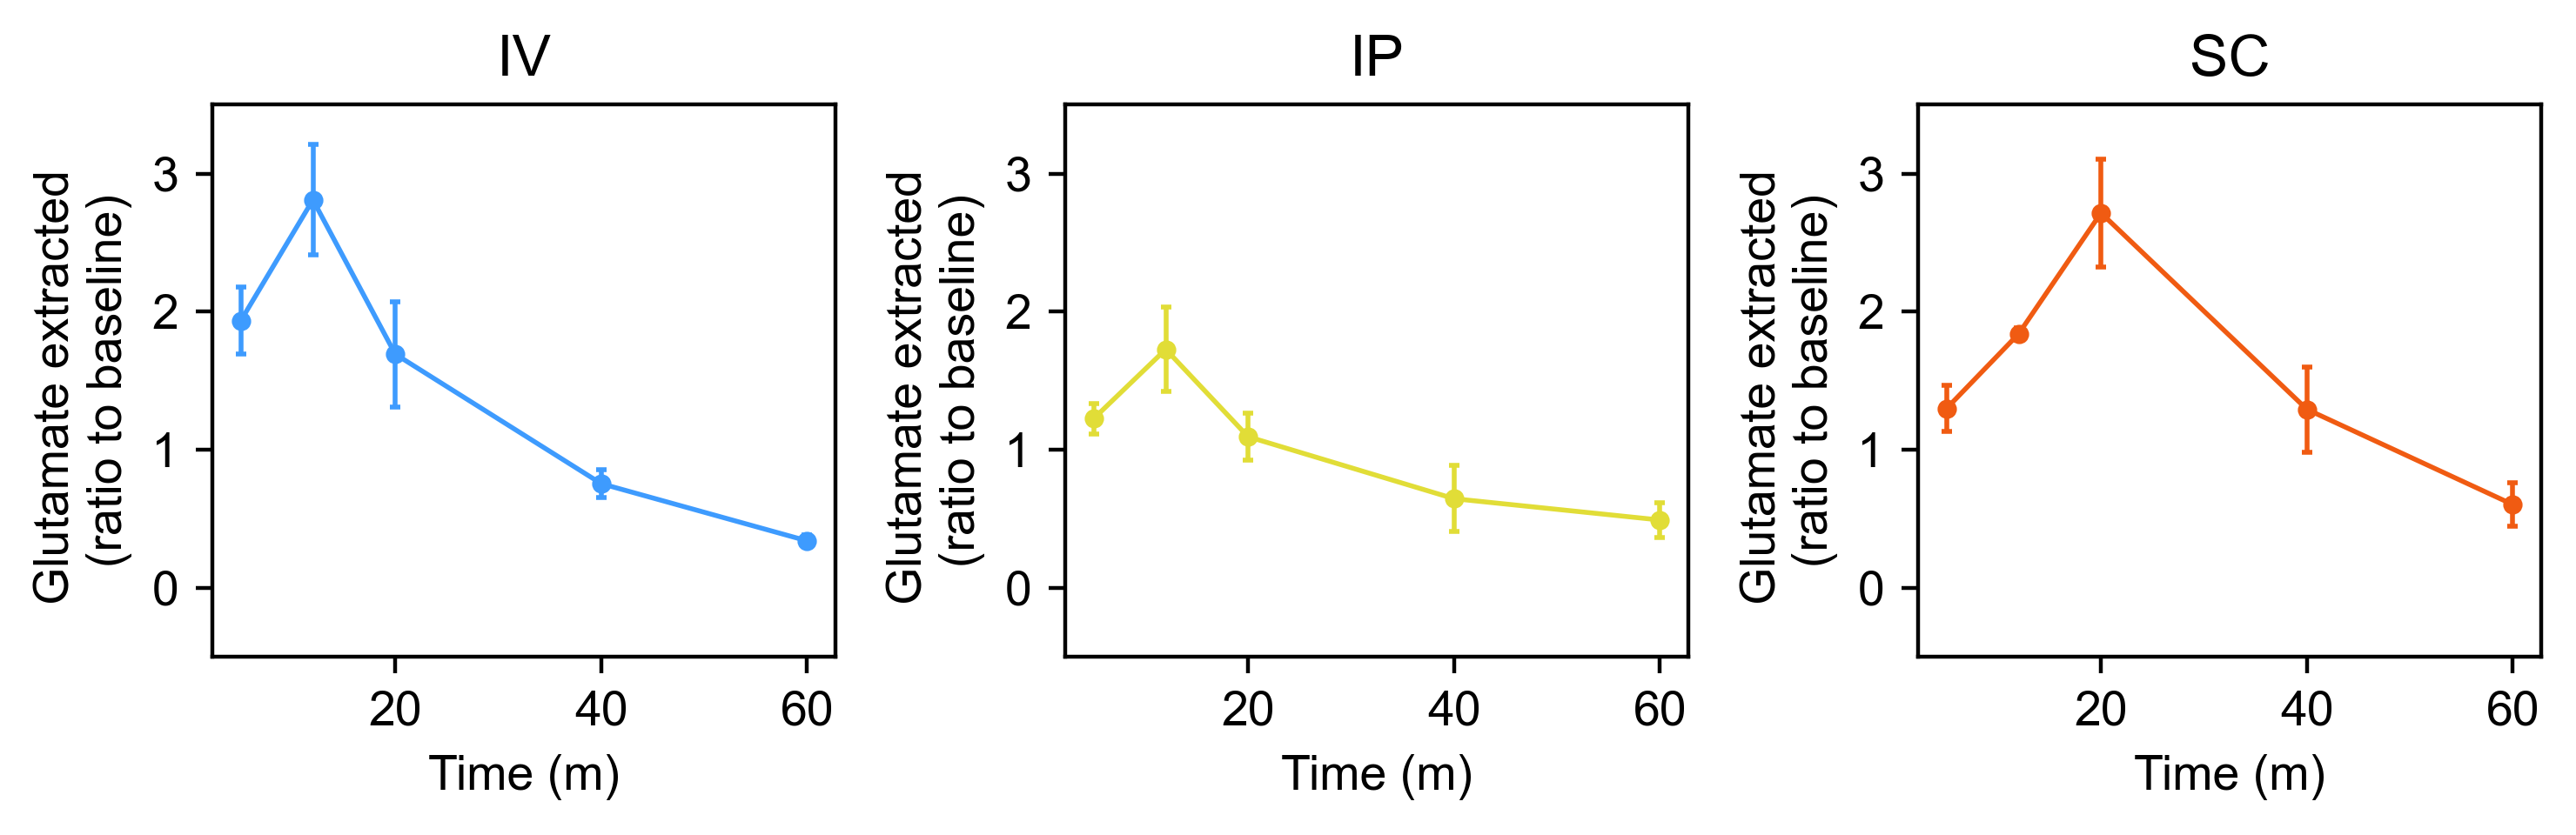

In [114]:
def load_pk(pk_path,drops=True):
    df = pd.read_csv(pk_path,index_col="Time")
    df = df.apply(pd.to_numeric, errors='coerce')
    if drops==True:
        # df.at[1.0,"R13"]=np.nan
        # df.at[1.0,"R3"]=np.nan
        # df.at[2.5,"R3"]=np.nan
        # df.at[5.0,"R3"]=np.nan
        # df.at[10.0,"R3"]=np.nan
        # df.at[20.0,"R3"]=np.nan
        # df.at[40.0,"R3"]=np.nan
        # df.at[60.0,"R3"]=np.nan
        #df.at[1.0,"R13"]=np.nan
        print("drop")
        #df.drop(index=62.0,inplace=True)
    return df

#Load the data
pk_path="/Users/snewbank/Documents/PhD/Data/25-03-16-glutamatebrainpk_ratios.csv"

IV=["R1","R3","R5","R7"]
IP=["R6","R8","R10","R12"]
SC=["R2","R4","R9","R11"]

cmap=plt.get_cmap("turbo")

drops_TF=True

groups={"IV" : IV, "IP" : IP, "SC" : SC}

drops_TF=True
df = load_pk(pk_path,drops=drops_TF)

#Making the 1-panel plot
plt.figure(figsize=(3,2),dpi=500)

df=df

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    plt.plot()
    plt.errorbar(df.index, m, yerr=std, color=colors[k],label=key,linewidth=0.5,capsize=1,markeredgewidth=0.5,markersize=2,marker="o")
    plt.xlabel('Time (m)')
    plt.ylabel('Glutamate extracted \n(ratio to baseline)')
    plt.legend()

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit_glutamateratio.png",dpi=500)
    

# Making the 3-panel plot
fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    ax[k].plot()
    ax[k].errorbar(df.index, m, yerr=std, color=colors[k],linewidth=1,capsize=1,markeredgewidth=1,markersize=3,marker="o")
    ax[k].set_xlabel('Time (m)')
    ax[k].set_ylabel('Glutamate extracted \n(ratio to baseline)')
    ax[k].set_title(key)
    ax[k].set_ylim([-0.5,3.5])

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit_panel_glutamateratio.png",dpi=500)

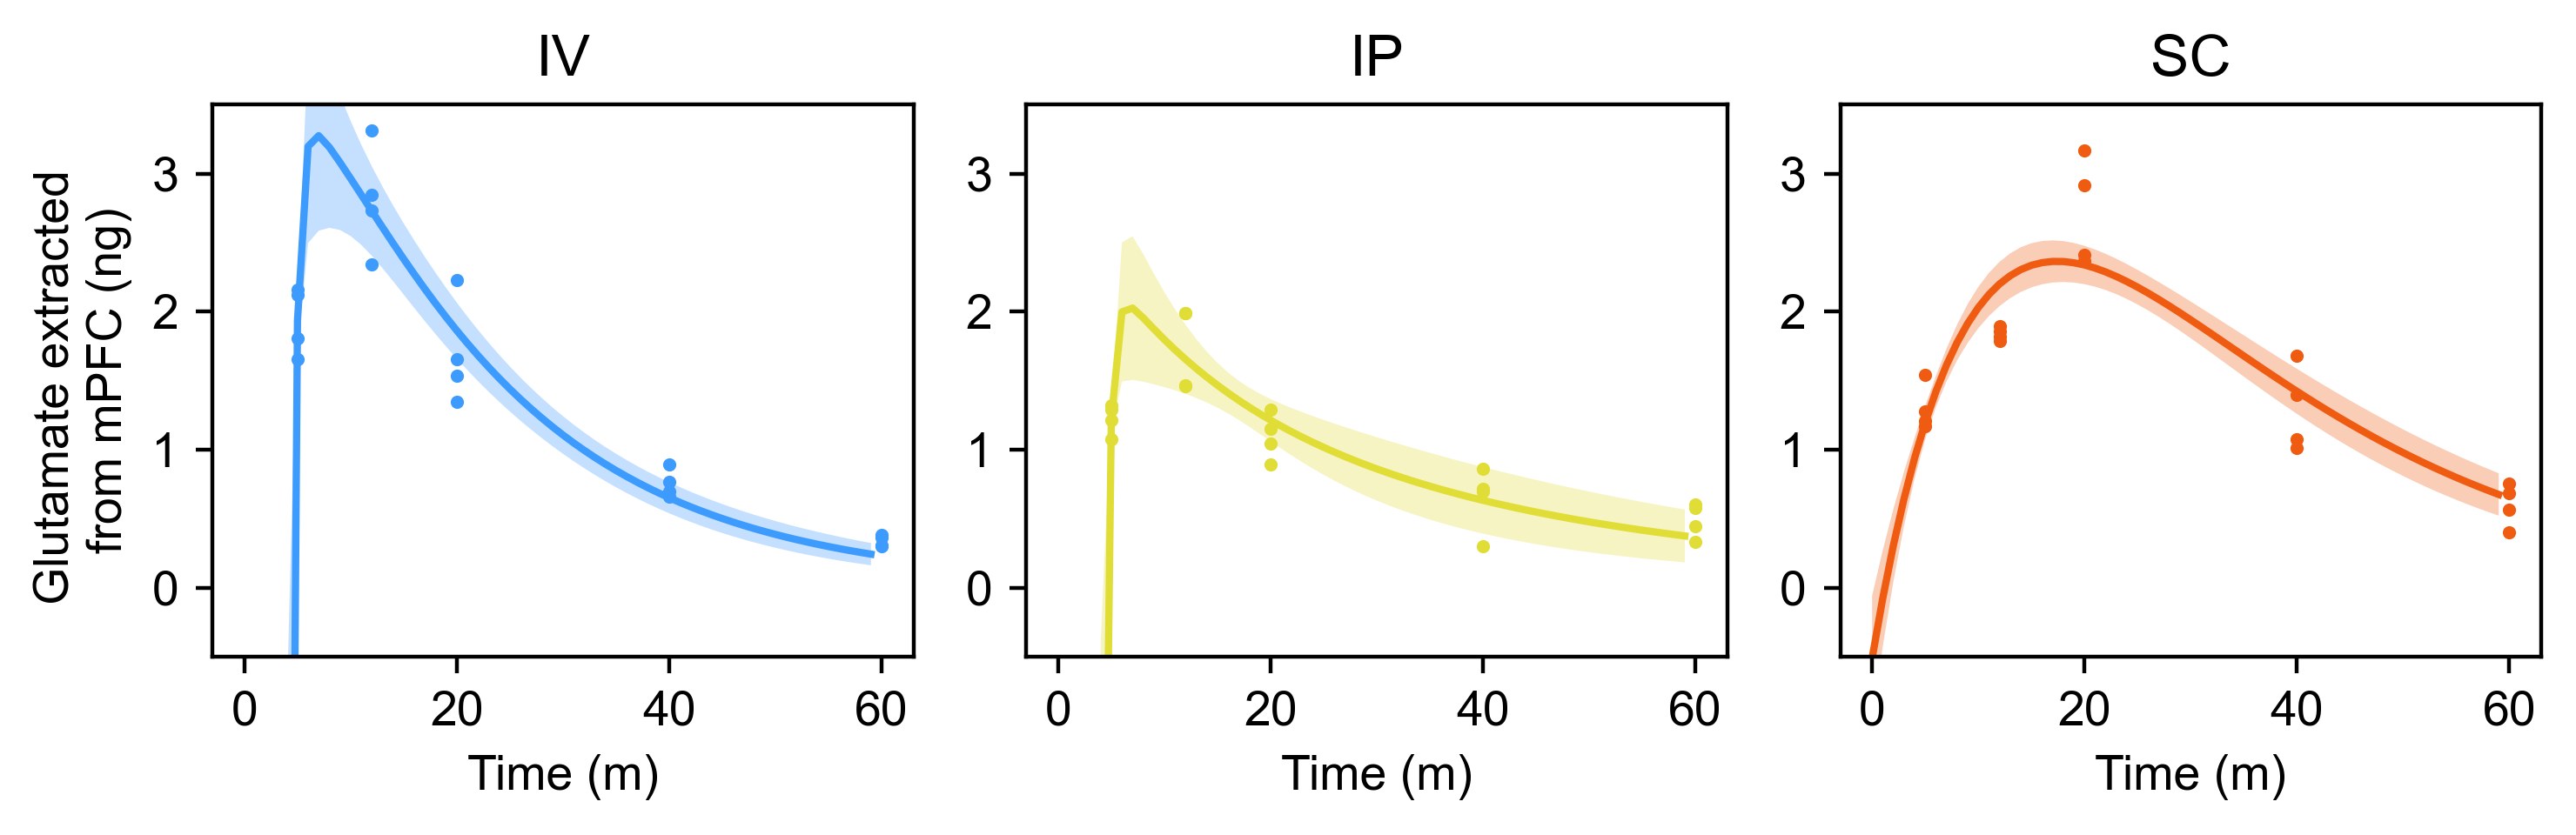

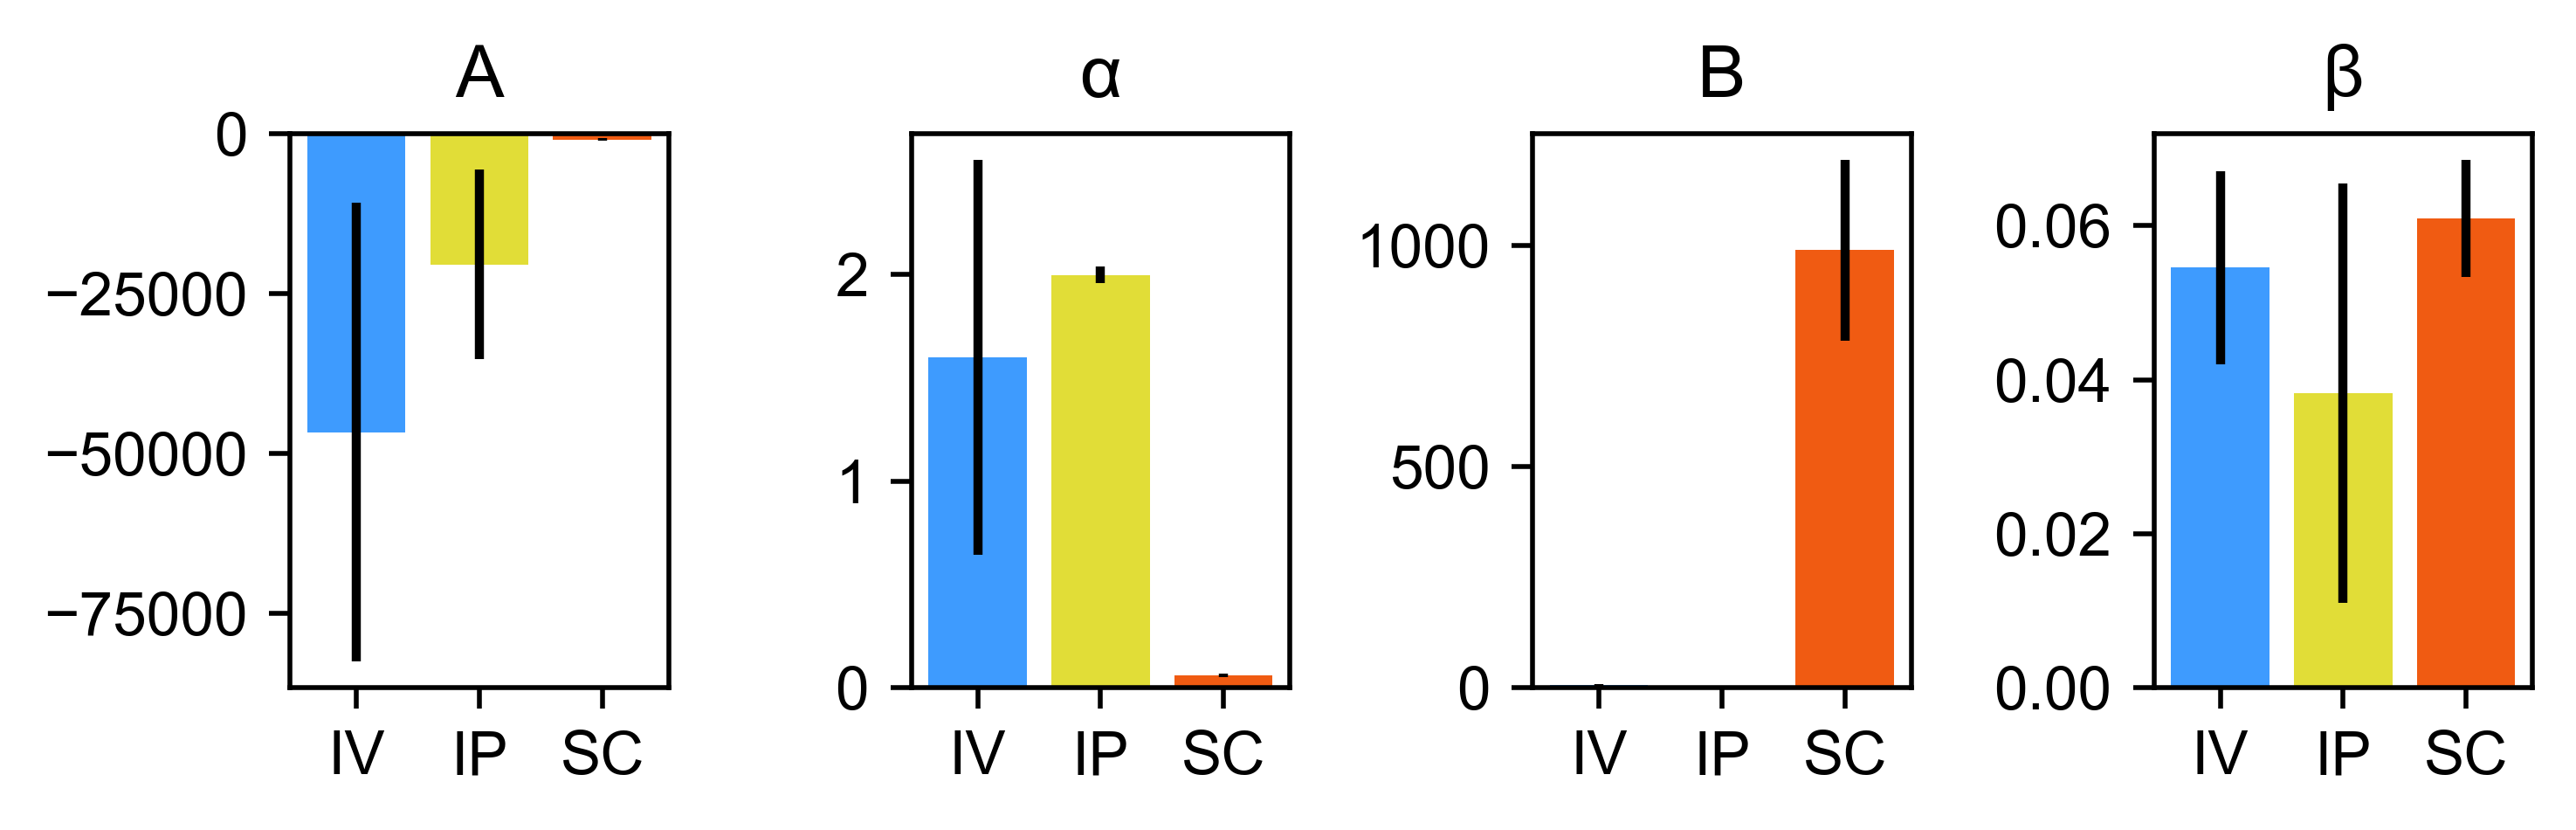

In [115]:
def biexponential(t, a, alpha, b, beta):
    return a * np.exp(-alpha * t) + b * np.exp(-beta * t)

def slope(point1, point2):
    return ((point1[1] - point2[1]) / (point1[0] - point2[0]))

def fit_to_biexponential(t,c):
    # Set initial "guess"
    p0=np.zeros(4)
    p0[0]=-10*slope([t[0],c[0]],[t[1],c[1]])
    p0[2]=-10*slope([t[np.argmax(c)],c[np.argmax(c)]],[t[-1],c[-1]])
    if np.argmax(c)!=0:
        p0[1] = 0.693/((t[np.argmax(c)]-t[0])/2)
    p0[3] = 0.693/((t[-1]-t[-2])/2)
    
    # Set bounds
    t0_to_peak=t[np.argmax(c)]
    peak_to_tlast=t[-1]-t[np.argmax(c)]
    
    bounds = ([-np.inf,0,-np.inf,0], [np.inf,t0_to_peak,np.inf,peak_to_tlast])
    
    for p,param in enumerate(p0):
        if param<bounds[0][p]:
            p0[p]=bounds[0][p]
        if param>bounds[1][p]:
            p0[p]=bounds[1][p]
    
    fit = optimize.curve_fit(biexponential, t, c, p0=p0, bounds=bounds, maxfev=10000)
    
    return fit

plot_types = ["mean_params","mean_fits"]
plot_type = plot_types[1]

groups={"IV" : IV, "IP" : IP, "SC" : SC}

cmap=plt.get_cmap("turbo")
colors={"IV": cmap([0.2]),"IP": cmap([0.6]),"SC": cmap([0.8])}

fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

all_fits=[]
for g, group in enumerate(groups.keys()):
    fits=[]
    subj=[]
    for i in range(len(df[groups[group]].columns)):
        data_i = df[groups[group]][df[groups[group]].columns[i]].dropna()
        if len(data_i)==0:
            continue
        subj.append(group+"_"+df[groups[group]].columns[i])
        t = data_i.index
        c = data_i.to_numpy()
        ax[g].scatter(t,c,color=colors[group],s=3)
        
        fit = fit_to_biexponential(t,c)
        fits.append(fit[0])
    
    if plot_type=="mean_params":
        fits=np.array(fits)
        mean_fit = np.mean(fits,axis=0)
        sd_fit = np.std(fits,axis=0)
        t=np.arange(0,60,1)
        c_fit_mean=biexponential(t,*mean_fit)
        hi_fit_mean=biexponential(t,*(mean_fit+sd_fit))
        lo_fit_mean=biexponential(t,*(mean_fit-sd_fit))
        ax[g].plot(t,c_fit_mean,color=colors[group])
        ax[g].fill_between(t,lo_fit_mean,hi_fit_mean,color=colors[group],alpha=0.3,edgecolor="none")
    elif plot_type=="mean_fits":
        t=np.arange(0,60,1)
        fit_curves=[]
        for fit in fits:
            fit_curves.append(biexponential(t,*fit))
        mean_fit = np.mean(np.array(fit_curves),axis=0)
        sd_fit = np.std(np.array(fit_curves),axis=0)
        ax[g].plot(t,mean_fit,color=colors[group])
        ax[g].fill_between(t,mean_fit-sd_fit,mean_fit+sd_fit,color=colors[group],alpha=0.3,edgecolor="none")
        fits=np.array(fits)
    ax[g].set_ylim([-0.5,3.5])
    ax[g].set_title(group)
    ax[g].set_xlabel("Time (m)")
    ax[0].set_ylabel('Glutamate extracted \nfrom mPFC (ng)')
    
    all_fits.append(pd.DataFrame({"A":fits[:,0],"α":fits[:,1],"B":fits[:,2],"β":fits[:,3]},index=subj))
plt.tight_layout()
fit_df = pd.concat(all_fits)
if save==True:
    plt.savefig(save_path+"roa_pk_glu_brain_fits.png",dpi=500)

fig, ax = plt.subplots(1,4,figsize=(6,2),dpi=500)

ticks=[]
labels=[]

for g, group in enumerate(groups.keys()):
    inds=[i for i in fit_df.index if i.startswith(group)]
    sub_df=fit_df.loc[inds]
    ticks.append(g)
    labels.append(group)
    for c,coeff in enumerate(fit_df.columns):
        mean=sub_df[coeff].mean()
        std=sub_df[coeff].std()
        ax[c].bar(x=g,height=mean,color=colors[group])
        ax[c].errorbar(g,mean,yerr=std,color="black")
        ax[c].set_title(coeff)

for c in range(len(fit_df.columns)):
    ax[c].set_xticks(ticks)
    ax[c].set_xticklabels(labels)
    ax[c].axhline(0,color="black",linewidth=0.5)
plt.tight_layout()
if save==True:
    plt.savefig(save_path+"roa_pk_glu_brain_fit_params.png",dpi=500)

In [116]:
selected_subgroups=["saliv"]
binsize=1200
labels_df  = analysis.get_module_labels(config,0,1200,subgroups=selected_subgroups)
control_usage_feats = analysis.get_module_usage(config,labels_df,binsize)
control_usage_feats.to_df()

selected_subgroups=["k10iv","k10ip","k10sc"]
binsize=60
labels_df = analysis.get_module_labels(config,0,60*50,subgroups=selected_subgroups)
exp_usage_feats = analysis.get_module_usage(config,labels_df,binsize)

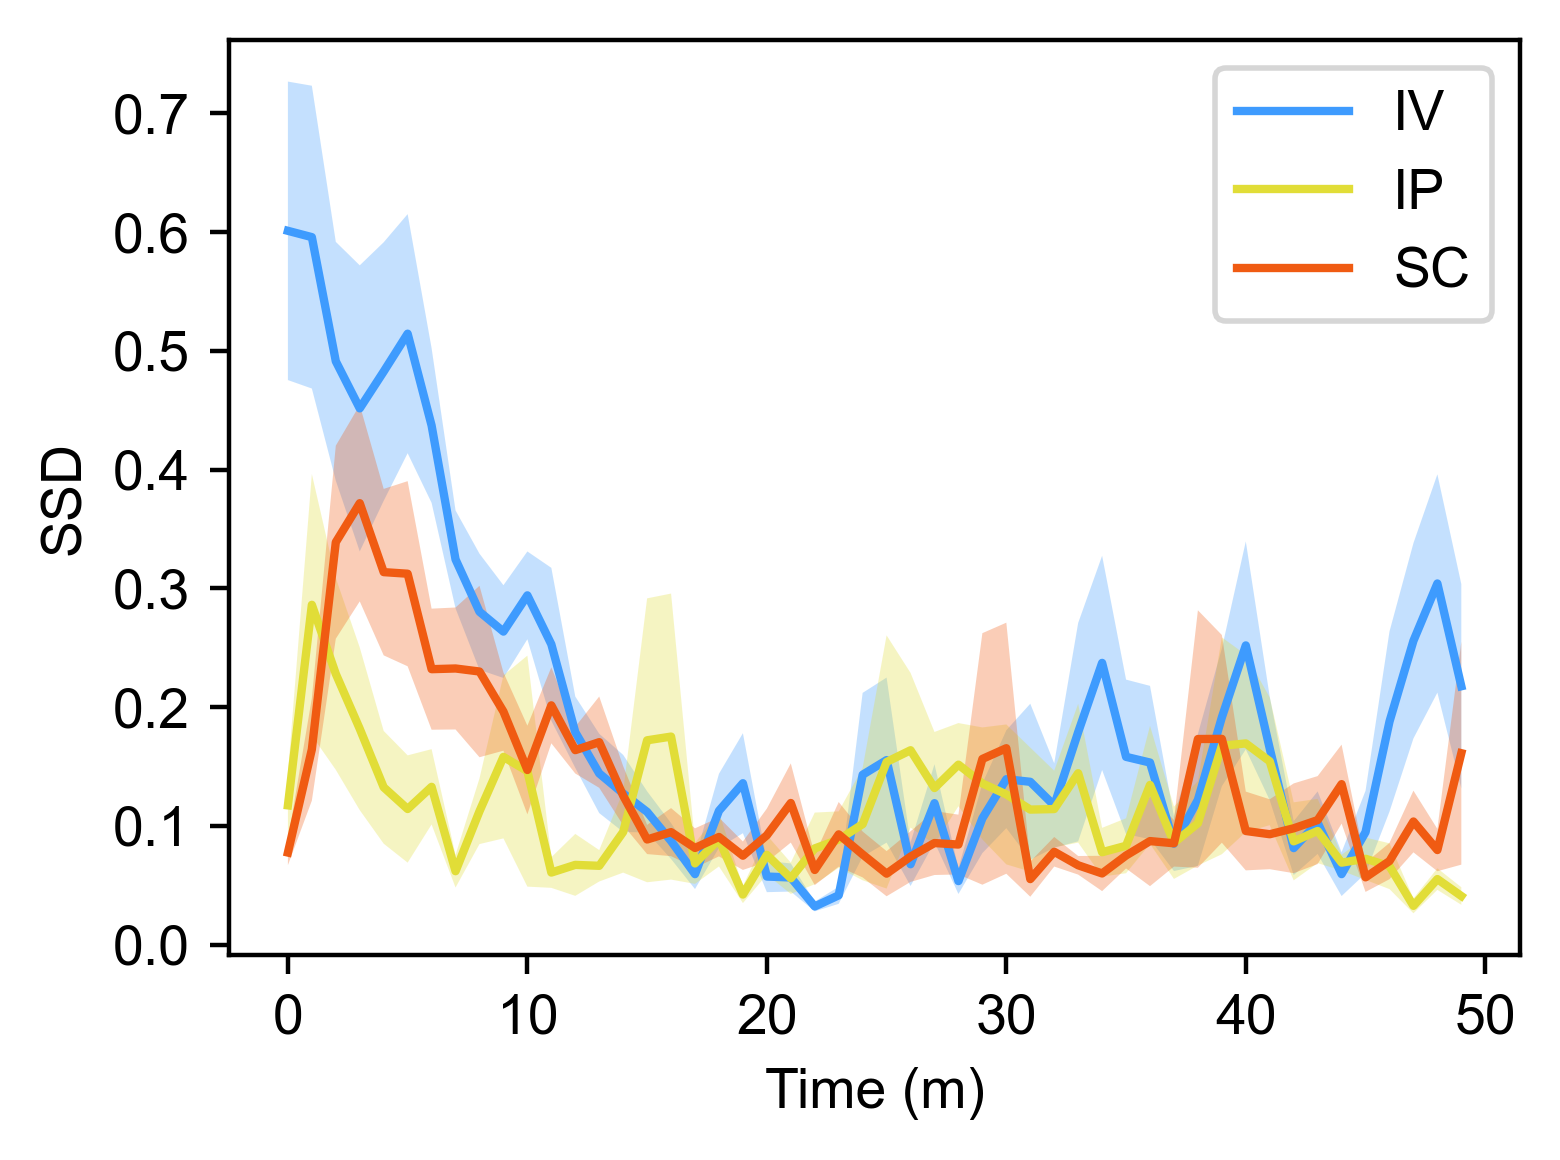

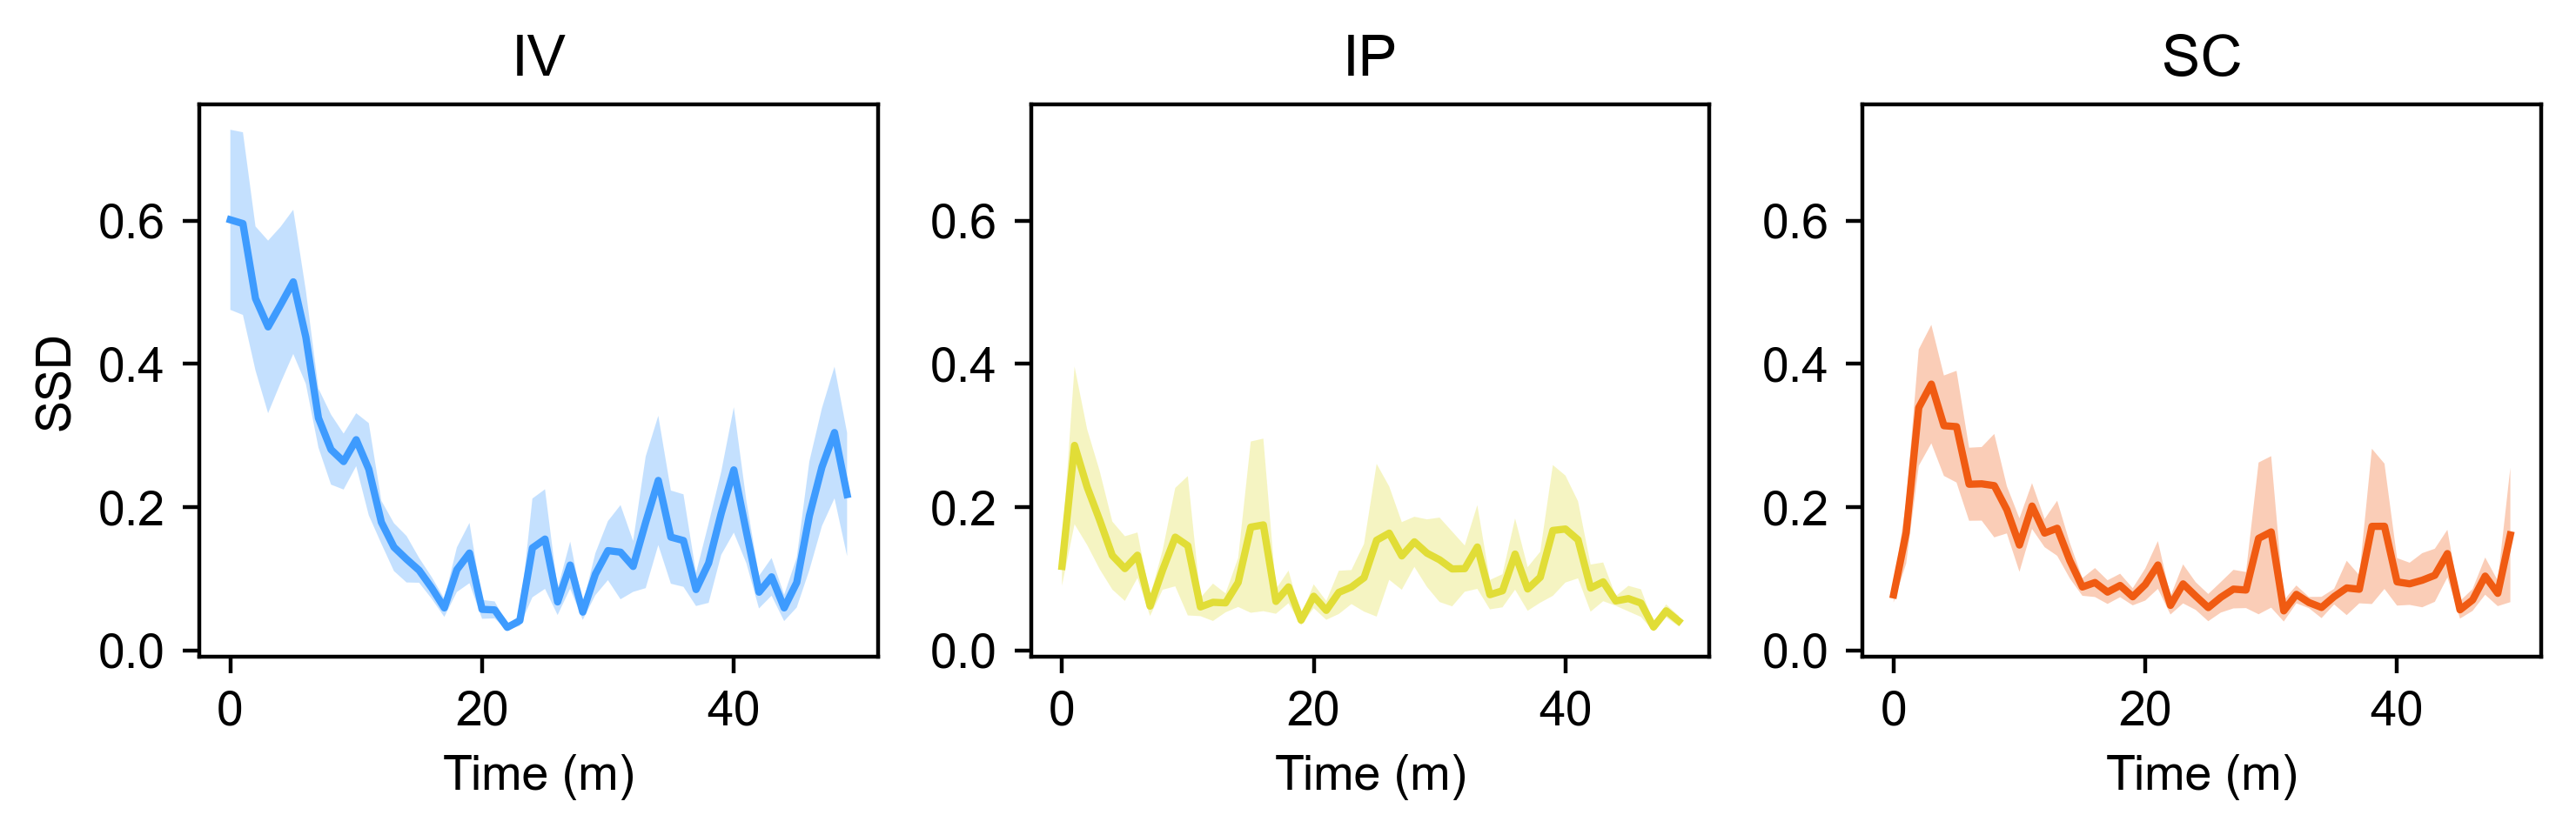

In [117]:
group_titles=["IV","IP","SC"]
cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

exp_usage_ssd = analysis.get_usage_ssd(control_usage_feats,exp_usage_feats)

plt.figure(figsize=(4,3),dpi=400)

xticks=np.float32(exp_usage_ssd.columns)/60
for g, group in enumerate(selected_subgroups):
    group_data=exp_usage_ssd.loc[config["subgroups"][group]]
    plt.plot(xticks,group_data.mean(axis=0),label=group_titles[g],color=colors[g])
    plt.fill_between(np.array(xticks),np.array(group_data.mean(axis=0)-(group_data.std(axis=0)/np.sqrt(group_data.shape[0])),dtype=np.float32),
                     np.array(group_data.mean(axis=0)+(group_data.std(axis=0)/np.sqrt(group_data.shape[0])),dtype=np.float32),color=colors[g],
                     alpha=0.3,edgecolor="none")
    
ylim=plt.ylim()
plt.xlabel("Time (m)")
plt.ylabel("SSD")
plt.legend()
plt.tight_layout()
if save==True:
    plt.savefig(save_path+"roa_pk_ssd_nofit.png",dpi=500)

fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

xticks=np.float32(exp_usage_ssd.columns)/60

for g, group in enumerate(selected_subgroups):
    group_data=exp_usage_ssd.loc[config["subgroups"][group]]
    ax[g].set_ylim(ylim)
    ax[g].plot(xticks,group_data.mean(axis=0),label=group,color=colors[g])
    ax[g].fill_between(np.array(xticks),np.array(group_data.mean(axis=0)-(group_data.std(axis=0)/np.sqrt(group_data.shape[0])),dtype=np.float32),
                     np.array(group_data.mean(axis=0)+(group_data.std(axis=0)/np.sqrt(group_data.shape[0])),dtype=np.float32),color=colors[g],
                     alpha=0.3,edgecolor="none")
    ax[g].set_title(group_titles[g])
    
    ax[g].set_xlabel("Time (m)")
ax[0].set_ylabel("SSD")
plt.tight_layout()
if save==True:
    plt.savefig(save_path+"roa_pk_ssd_nofit_panels.png",dpi=500)

In [118]:
behavior_pk = exp_usage_ssd.T
behavior_pk.index = np.array(behavior_pk.index,dtype=float)
new_columns=[]
for c,column in enumerate(behavior_pk.columns):
    new_columns.append("subj"+str(c)+"_"+column)
behavior_pk.columns=new_columns

In [119]:
behavior_pk

,subj0_2023-05-15_16-47-52_bf03_k10iv,subj1_2023-05-15_18-18-22_bf04_k10iv,subj2_2023-05-25_14-30-54_bm02_k10iv,subj3_2023-05-31_17-08-06_bf01_k10iv,subj4_2023-07-13_15-45-26_bm03_k10iv,subj5_2023-07-14_13-56-09_bm01_k10iv,subj6_2023-07-18_18-19-50_bm04_k10iv,subj7_2023-05-09_18-06-23_bf02_k10ip,subj8_2023-05-15_12-01-26_bm03_k10ip,subj9_2023-05-20_17-11-22_bm01_k10ip,subj10_2023-05-31_19-08-34_bf04_k10ip,subj11_2023-06-15_19-46-22_bf01_k10ip,subj12_2023-07-13_16-56-46_bm04_k10ip,subj13_2023-05-21_16-17-57_bf02_k10sc,subj14_2023-05-30_14-08-51_bm02_k10sc,subj15_2023-06-20_17-54-10_bf03_k10sc,subj16_2023-07-03_15-04-47_bm01_k10sc,subj17_2023-07-08_16-55-20_bm03_k10sc,subj18_2023-07-21_18-00-15_bf04_k10sc
0.0,0.539348,0.531993,0.260495,0.626452,0.188769,1.030693,1.029556,0.215333,0.02788,0.082787,0.168147,0.095833,0.113444,0.111009,0.094753,0.053877,0.059884,0.049729,0.095794
60.0,0.719836,0.498094,0.186667,0.485546,0.2456,1.030693,1.003761,0.722629,0.085229,0.112976,0.521289,0.098881,0.175786,0.375332,0.148127,0.102574,0.146823,0.092819,0.120682
120.0,0.399958,0.439409,0.292622,0.513607,0.551808,1.030693,0.210394,0.464504,0.11623,0.029013,0.485185,0.087071,0.185719,0.676906,0.202043,0.244836,0.434909,0.122045,0.352304
180.0,0.761849,0.235163,0.308747,0.340881,0.312874,1.030693,0.17049,0.376514,0.064779,0.047118,0.409327,0.048504,0.143961,0.740962,0.246055,0.260487,0.282799,0.223841,0.476114
240.0,0.49024,0.229118,0.330779,0.688393,0.259775,1.030693,0.34886,0.175916,0.043493,0.04785,0.347846,0.072137,0.107427,0.531394,0.266394,0.194687,0.188425,0.169982,0.530972
300.0,0.435223,0.348348,0.614387,0.602939,0.316017,1.030693,0.253539,0.133998,0.039203,0.016508,0.323669,0.076085,0.095593,0.338331,0.329414,0.254493,0.163605,0.12706,0.660906
360.0,0.30088,0.407302,0.40984,0.464479,0.507331,0.756801,0.213299,0.104615,0.064842,0.271863,0.17289,0.077403,0.105484,0.337017,0.151931,0.114739,0.187583,0.166849,0.43338
420.0,0.243997,0.355607,0.331487,0.381189,0.510617,0.277425,0.17018,0.098522,0.02248,0.067396,0.100115,0.026517,0.055747,0.354887,0.181755,0.142799,0.171405,0.119365,0.424796
480.0,0.228985,0.418724,0.259508,0.323731,0.452105,0.079854,0.199104,0.089261,0.175593,0.212253,0.069216,0.093782,0.033554,0.323891,0.128009,0.122384,0.179741,0.079117,0.546569
540.0,0.313094,0.421841,0.182101,0.366824,0.164535,0.176743,0.219843,0.018104,0.314964,0.421357,0.08158,0.080981,0.031421,0.281025,0.211615,0.11948,0.16194,0.106695,0.296618


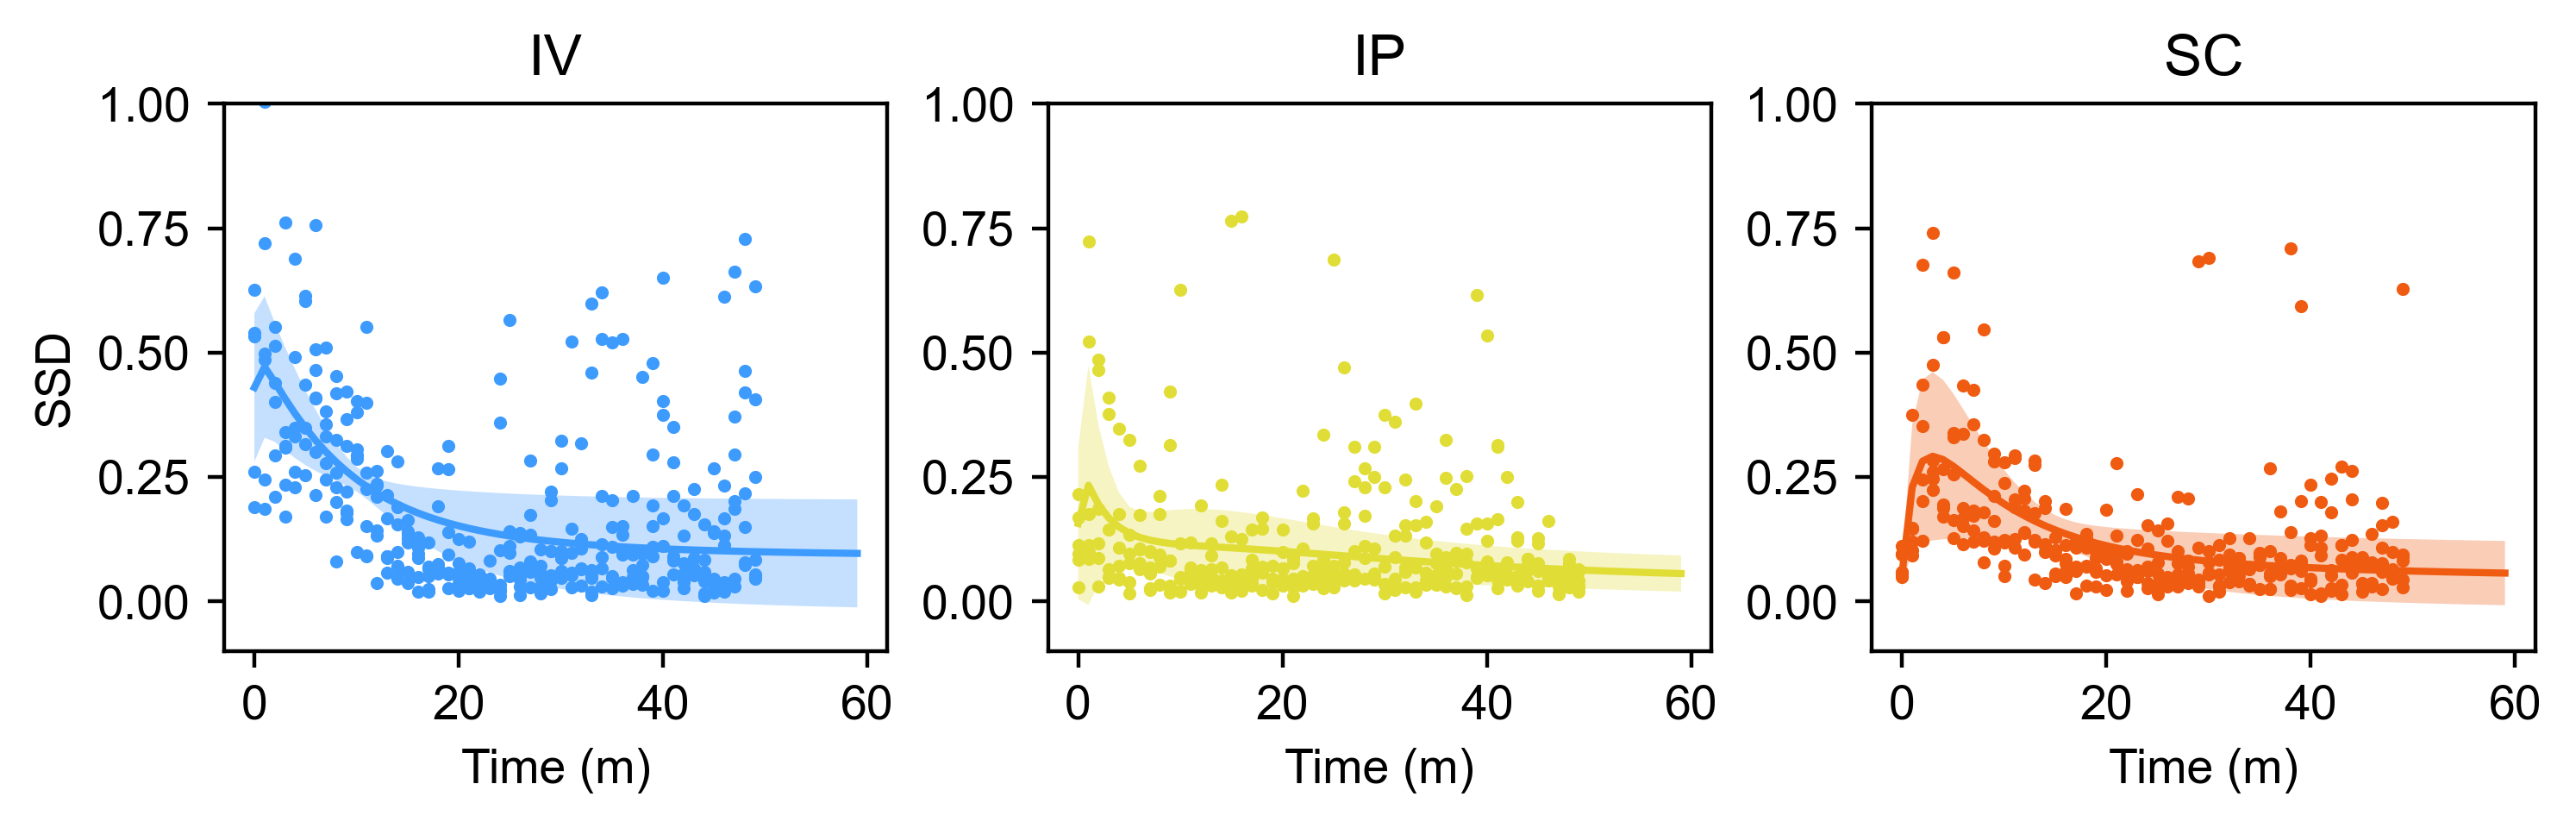

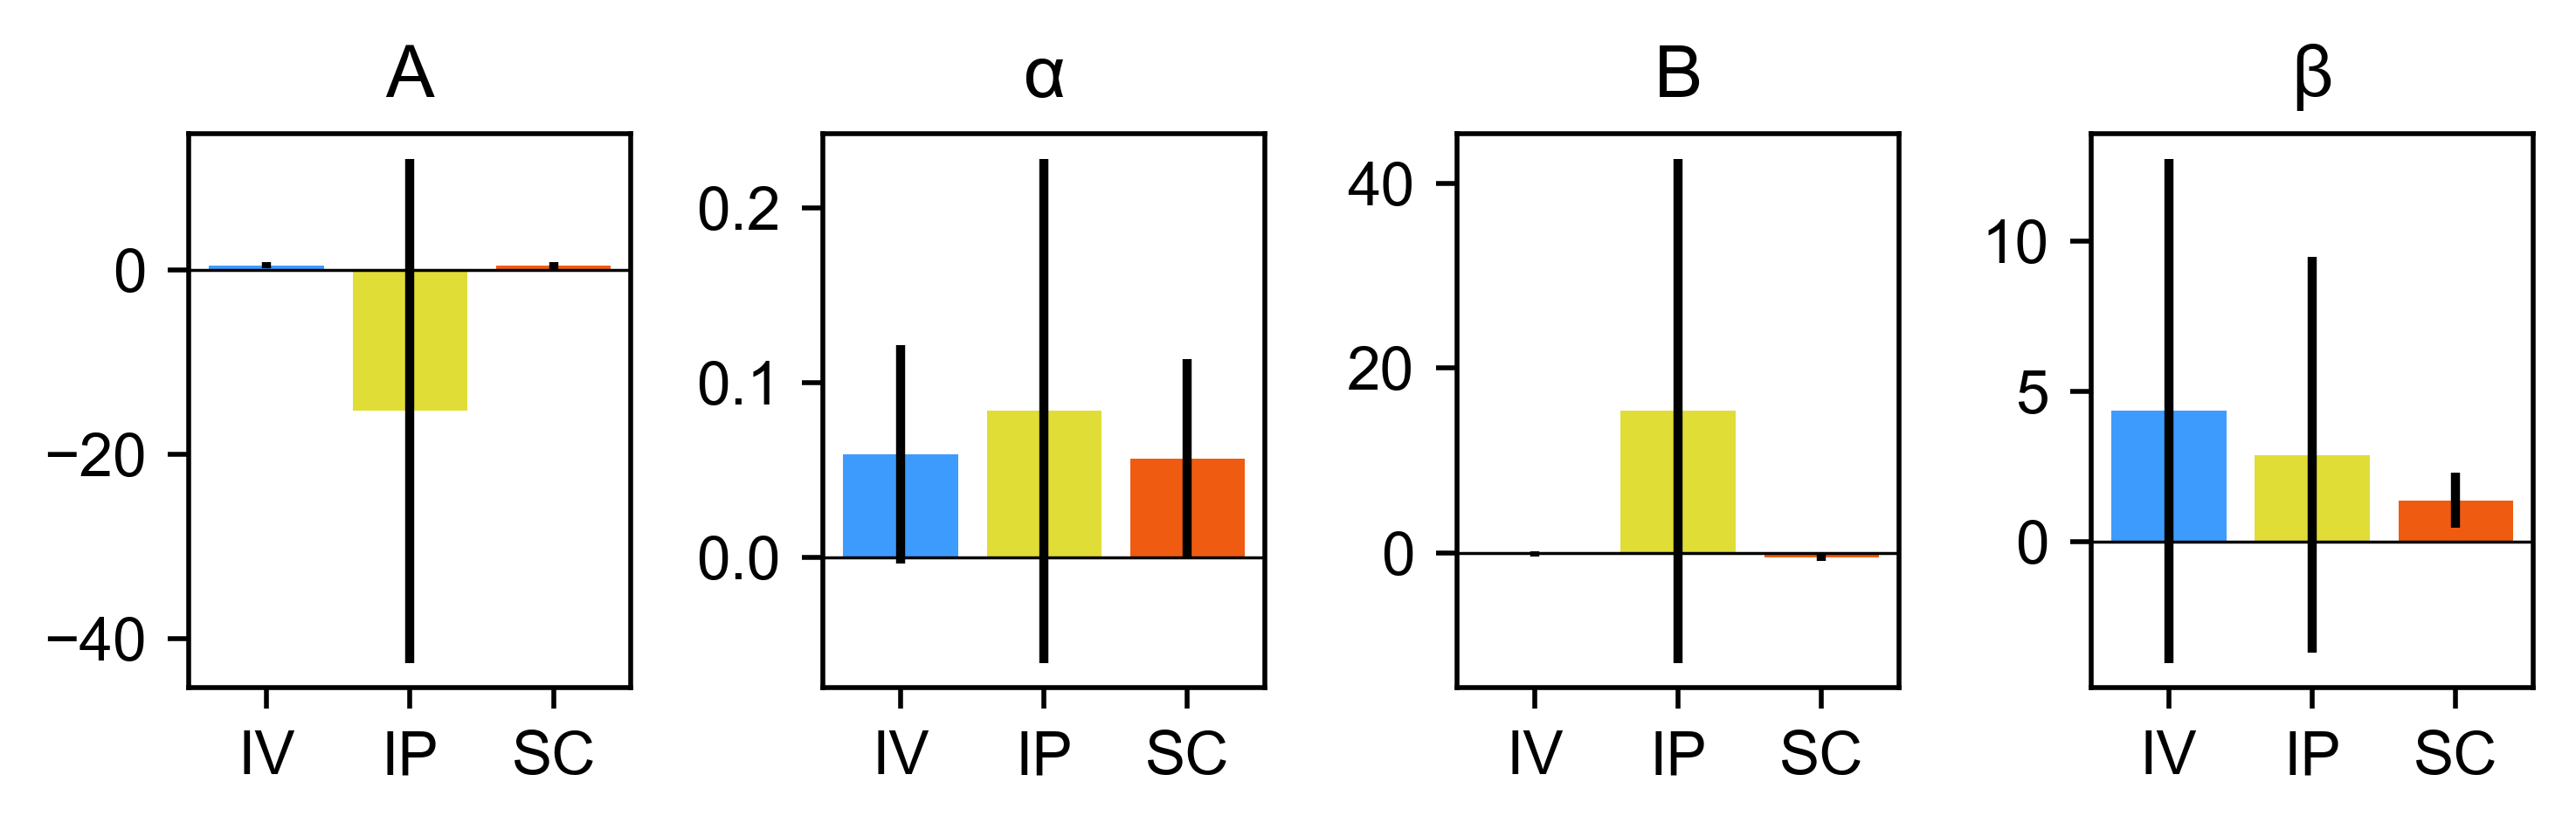

In [120]:
def biexponential(t, a, alpha, b, beta):
    return a * np.exp(-alpha * t) + b * np.exp(-beta * t)

def slope(point1, point2):
    return ((point1[1] - point2[1]) / (point1[0] - point2[0]))
    

groups={"IV" : [i for i in behavior_pk.columns if "k10iv" in i], 
        "IP" : [i for i in behavior_pk.columns if "k10ip" in i], 
        "SC" : [i for i in behavior_pk.columns if "k10sc" in i]}

df = behavior_pk

cmap=plt.get_cmap("turbo")
colors={"IV": cmap([0.2]),"IP": cmap([0.6]),"SC": cmap([0.8])}

fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

all_fits=[]
for g, group in enumerate(groups.keys()):
    fits=[]
    subj=[]
    for i in range(len(df[groups[group]].columns)):
        try:
            data_i = df[groups[group]][df[groups[group]].columns[i]].dropna()
            if len(data_i)==0:
                continue
            t = np.array(data_i.index)/60
            c = data_i.to_numpy()
            ax[g].scatter(t,c,color=colors[group],s=3)
            fit = fit_to_biexponential(t,c)
            fits.append(fit[0])
            subj.append(group+"_"+df[groups[group]].columns[i])
            #ax[g].plot(t,biexponential(t,*fit[0]))
        except:
            continue
    
    if plot_type=="mean_params":
        fits=np.array(fits)
        mean_fit = np.mean(fits,axis=0)
        sd_fit = np.std(fits,axis=0)
        t=np.arange(0,60,1)
        c_fit_mean=biexponential(t,*mean_fit)
        hi_fit_mean=biexponential(t,*(mean_fit+sd_fit))
        lo_fit_mean=biexponential(t,*(mean_fit-sd_fit))
        ax[g].plot(t,c_fit_mean,color=colors[group])
        ax[g].fill_between(t,lo_fit_mean,hi_fit_mean,color=colors[group],alpha=0.3,edgecolor="none")
    elif plot_type=="mean_fits":
        t=np.arange(0,60,1)
        fit_curves=[]
        for fit in fits:
            fit_curves.append(biexponential(t,*fit))
        mean_fit = np.mean(np.array(fit_curves),axis=0)
        sd_fit = np.std(np.array(fit_curves),axis=0)
        ax[g].plot(t,mean_fit,color=colors[group])
        ax[g].fill_between(t,mean_fit-sd_fit,mean_fit+sd_fit,color=colors[group],alpha=0.3,edgecolor="none")
        fits=np.array(fits)
    ax[g].set_ylim([-0.1,1])
    ax[g].set_title(group)
    ax[g].set_xlabel("Time (m)")
    ax[0].set_ylabel("SSD")
    
    all_fits.append(pd.DataFrame({"A":fits[:,0],"α":fits[:,1],"B":fits[:,2],"β":fits[:,3]},index=subj))
plt.tight_layout()
fit_df = pd.concat(all_fits)
if save==True:
    plt.savefig(save_path+"roa_pk_ssd_fit.png",dpi=500)


fig, ax = plt.subplots(1,4,figsize=(6,2),dpi=500)

ticks=[]
labels=[]

for g, group in enumerate(groups.keys()):
    inds=[i for i in fit_df.index if i.startswith(group)]
    sub_df=fit_df.loc[inds]
    ticks.append(g)
    labels.append(group)
    for c,coeff in enumerate(fit_df.columns):
        mean=sub_df[coeff].mean()
        std=sub_df[coeff].std()
        ax[c].bar(x=g,height=mean,color=colors[group])
        ax[c].errorbar(g,mean,yerr=std,color="black")
        ax[c].set_title(coeff)

for c in range(len(fit_df.columns)):
    ax[c].set_xticks(ticks)
    ax[c].set_xticklabels(labels)
    ax[c].axhline(0,color="black",linewidth=0.5)
plt.tight_layout()
if save==True:
    plt.savefig(save_path+"roa_pk_ssd_fit_params.png",dpi=500)

In [121]:
figW=3
figH=2


group="k10sc"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title="K10-SC",figW=figW,figH=figH,legend=False)
if save==True:
    plt.savefig(save_path+group+"_sandplot.png",dpi=500, bbox_inches='tight')
group="k10iv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title="K10-IV",figW=figW,figH=figH,legend=False)
if save==True:
    plt.savefig(save_path+group+"_sandplot.png",dpi=500, bbox_inches='tight')
group="k10ip"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title="K10-IP",figW=figW,figH=figH,legend=False)
if save==True:
    plt.savefig(save_path+group+"_sandplot.png",dpi=500, bbox_inches='tight')
group="saliv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 20,title="Sal-IV",figW=2,figH=figH,legend=False)
if save==True:
    plt.savefig(save_path+group+"_sandplot.png",dpi=500, bbox_inches='tight')

group="saliv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 20,title="Sal-IV",figW=7,figH=figH,legend=True)
if save==True:
    plt.savefig(save_path+group+"_sandplot_LEGEND.png",dpi=500, bbox_inches='tight')

AttributeError: module 'utils.analysis' has no attribute 'label_counter_subgroups'

done with ['2023-07-18_18-19-50_bm04_k10iv_2023-07-18_18-19-50_bm04_k10iv.csv', '2023-07-18_18-19-50_bm04_k10iv']
done with ['2023-06-20_19-10-38_bf04_k1iv_2023-06-20_19-10-38_bf04_k1iv.csv', '2023-06-20_19-10-38_bf04_k1iv']
VAME modules map onto scored behaviors with 'loss' of 0.3304357516995431


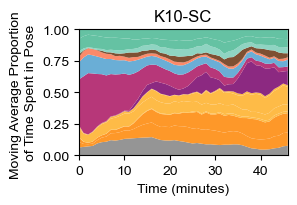

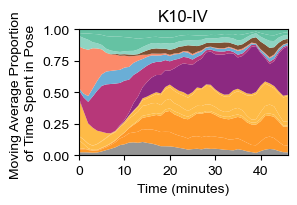

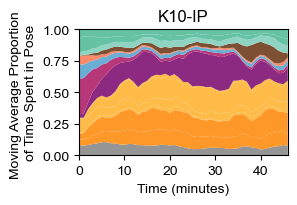

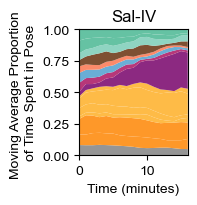

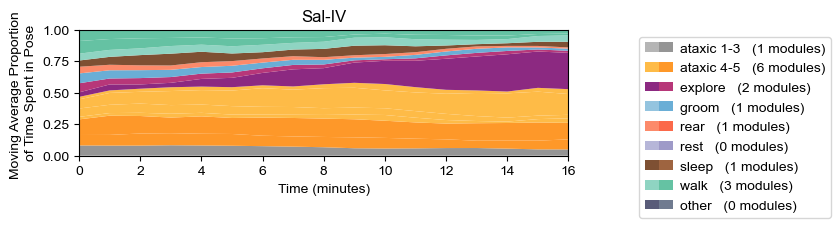

In [16]:
figW=3
figH=2
importlib.reload(plot)

BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
analysis.make_remappings_from_BORIS(config, BORIS_to_pose_mat=BORIS_to_pose_mat)

group="k10sc"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title="K10-SC",figW=figW,figH=figH,BORIS_to_pose_mat=BORIS_to_pose_mat,legend=False)
if save==True:
    plt.savefig(save_path+group+"_remapped_sandplot.png",dpi=500, bbox_inches='tight')
group="k10iv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title="K10-IV",figW=figW,figH=figH,BORIS_to_pose_mat=BORIS_to_pose_mat,legend=False)
if save==True:
    plt.savefig(save_path+group+"_remapped_sandplot.png",dpi=500, bbox_inches='tight')
group="k10ip"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50,title="K10-IP",figW=figW,figH=figH,BORIS_to_pose_mat=BORIS_to_pose_mat,legend=False)
if save==True:
    plt.savefig(save_path+group+"_remapped_sandplot.png",dpi=500, bbox_inches='tight')
group="saliv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 20,title="Sal-IV",figW=2,figH=figH,BORIS_to_pose_mat=BORIS_to_pose_mat,legend=False)
if save==True:
    plt.savefig(save_path+group+"_remapped_sandplot.png",dpi=500, bbox_inches='tight')

group="saliv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 20,title="Sal-IV",figW=10,figH=figH,
                                             legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,long_legend=True)
if save==True:
    plt.savefig(save_path+group+"_remapped_sandplot_LEGEND.png",dpi=500, bbox_inches='tight')